#Trabalho de Conclusão de Curso
#Especialização em Ciência de Dados
Prof. Eduardo Kugler Viegas<BR>
Alunos: Humberto Pradera e Leonardo Rocha

Experimentos para subsidiar a escrita do artigo<BR>

Utilizamos a versão NetFlow v3 Datasets

Visualização dos gráficos e experimento crossdataset

# Preâmbulo

# Imports, variáveis e funções gerais

In [1]:
!pip install tabulate
!pip install fastai
!pip install tensorflow

In [2]:
#Bibliotecas
import numpy as np
import pandas as pd
import copy #copiar o modelo em memória

import gc

from tabulate import tabulate  #print de tabela
import itertools #usado na formatação da matriz de confusão


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

#shrink memory dataset
from fastai.tabular.core import df_shrink

#CNN/MLP
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense,  Dropout
from tensorflow.keras.models import Model, Sequential

from google.colab import drive
import math
from time import time as time2
import datetime
#import time

# Para plotagem 3D
from mpl_toolkits.mplot3d import Axes3D


In [3]:
# Variavel que será redefinida posteriormente
attack_categories = ['Benigno', 'Ataque']

In [4]:
lista_campos_excluir = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT', 'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS',
                        'DNS_QUERY_ID', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'MIN_TTL', 'MAX_TTL']
lista_campos_verif = ['SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES']

In [5]:
# Plotar a matrix de confusão
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues,
                          figsize=(9, 6)): # Add figsize parameter with a default value
  plt.figure(figsize=figsize) # Use the figsize parameter here
  plt.imshow(cm, interpolation = 'nearest',cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation = 45)
  plt.yticks(tick_marks, classes)

  if normalize:
    cm = cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]
    print("Normalized confusion matrix")
  else:
    print("Confusion matrix, without normalization")

  print(cm)

  thresh = cm.max()/2
  for i, j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
    plt.text(j, i, cm[i,j], horizontalalignment="center", color="white" if cm[i,j]>thresh else "black")

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

In [6]:
#Formata um número em bytes para Megabytes
def format_megabytes(size_in_bytes):
  if size_in_bytes is None:
    return "N/A"
  size_in_mb = size_in_bytes / (1024 * 1024)
  return f"{size_in_mb:.2f} MB"


In [7]:
#avaliando if epochs foi bem definida
def plot_history(results):
  # Plot accuracy
  plt.plot(results.history['accuracy'], label='Training Accuracy')
  plt.plot(results.history['val_accuracy'], label='Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.title('Accuracy vs Epochs')
  plt.show()

  # Plot loss
  plt.plot(results.history['loss'], label='Training Loss')
  plt.plot(results.history['val_loss'], label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.title('Loss vs Epochs')
  plt.show()


In [8]:
# Controle de alguns experimentos
QUANTIDADE_MINIMA_CLASSE = 1000
HIGIENIZAR_DATASETS = True
BALANCEAR_DATASETS = True
TEST_SIZE = 0.2

In [9]:
def balacear_dataset(pdf):

  if not BALANCEAR_DATASETS:
    print("- Dataset não será balanceado")
    return pdf

  attack_counts = pdf['Attack'].value_counts()
  print("- attack_counts:",attack_counts,"\n")

  min_attack_count = attack_counts[attack_counts.index != 'Benign'].min()
  print("min_attack_count:",min_attack_count)

  benign_count = attack_counts['Benign']
  print("benign_count:", benign_count)

  # Calcula o valor alvo para as classes maliciosas
  target_non_benign_count = min(min_attack_count, benign_count // (len(attack_counts) - 1))
  print("- Quantidade inicial mínima para cada classe de ataque:",target_non_benign_count)

  if target_non_benign_count<QUANTIDADE_MINIMA_CLASSE:
    print(f"-- Então a quantidade inicial mínima é menor que {QUANTIDADE_MINIMA_CLASSE}. O Dataset terá problema no balanceamento.")
    # Se a quantidade inicial or menor que 1000, então teremos um Dataset balanceado com muito poucos casos.
    # Para evitar isto, busco a classe que possua menor representação que tenha quantidade de ocorrências maior que 1000
    # Pego a totalização por tipo de ataque
    vc = pdf['Attack'].value_counts()
    # Filtro de quantidade mínima, estipulada pelo professor como 1000
    vc1k = vc[vc>QUANTIDADE_MINIMA_CLASSE]
    # Pego o último valor, que deve ser o menor valor superior a 1000
    target_non_benign_count = vc1k.tail(1).values[0]
    print("-- Novo valor mínimo encontrado:",target_non_benign_count)

  # De fato faz o balanceamento
  balanced_dfs = []
  for attack_type in attack_counts.index:
    if attack_type == 'Benign':
      balanced_dfs.append(pdf[pdf['Attack'] == 'Benign'].sample(min(benign_count, target_non_benign_count * (len(attack_counts) - 1)), random_state=42))
    else:
      balanced_dfs.append(pdf[pdf['Attack'] == attack_type].sample(min(attack_counts[attack_type], target_non_benign_count), random_state=42))

  alldf = pd.concat(balanced_dfs)

  print("\nResultado do balanceamento:")
  attack_counts = alldf['Attack'].value_counts()
  print("- attack_counts:",attack_counts,"\n")

  return alldf

In [10]:
def higienizar_dataset(pdf):

  if not HIGIENIZAR_DATASETS:
    print("- Dataset não será higienizado")
    return

  qtd_ini = len(pdf)
  print("- Tamanho original do Dataset: {:,}".format(qtd_ini))

  # Drop rows where SRC_TO_DST_SECOND_BYTES or DST_TO_SRC_SECOND_BYTES have infinite values or values > np.finfo(np.float64).max
  print("- Removendo registros com campos com valor infinito ou superior a np.float64")
  for col in lista_campos_verif:
    pdf.drop(pdf[np.isinf(pdf[col])].index, inplace=True)
    pdf.drop(pdf[pdf[col] > np.finfo(np.float64).max].index, inplace=True)

  #retira registros com campos NA
  print("- Removendo registros com campos NA")
  pdf.dropna(subset=['SRC_TO_DST_SECOND_BYTES'], inplace=True)

  # verificando se há linhas duplicadas
  qtd_duplicadas = pdf.duplicated().sum()

  if qtd_duplicadas > 0:
    print("- Encontrados {:,} registros duplicados".format(qtd_duplicadas))
    # retirando as linhas duplicadas
    pdf.drop_duplicates(inplace=True)
    pdf.reset_index(inplace=True, drop=True)

  qtd_fim = len(pdf)
  print("- Ao total, foram eliminados {:,} registros".format(qtd_ini-qtd_fim))
  print("- Tamanho final {:,}".format(qtd_fim))

# Datasets

In [11]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


In [12]:
df_url = []
df = []

df_url.append('/content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Dataset/NF-UNSW-NB15-v3/data/NF-UNSW-NB15-v3.csv')
df_url.append('/content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Dataset/NF-ToN-IoT-v3/data/NF-ToN-IoT-v3.csv')
df_url.append('/content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Dataset/NF-BoT-IoT-v3/data/NF-BoT-IoT-v3.csv')
df_url.append('/content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Dataset/NF-CSE-CIC-IDS2018-v3/data/NF-CICIDS2018-v3.csv')

tamanho_antes = 0
tamanho_depois = 0

#limita a quantidade de registros a carregar ao mesmo tempo em memóris
#para permitir uma máquina com mesmo tempo processar os Datasets
chunk_size = 4000000
chunk_resultset = []

#loop carregando os datasets
for index, d in enumerate(df_url):
  #carrega
  print("\n--- Dataset",index+1,'---')

  #cria um iterator para ler o arquivo em pedaços
  chunk_iter = pd.read_csv(d, chunksize=chunk_size)

  chunk_number = 0
  for chunk in chunk_iter:
    chunk_number += 1
    print(f"---- Processando chunk {chunk_number} ----")
    print("- Lidas {:,} linhas.".format(len(chunk)))

    tamanho_memoria_ds = chunk.memory_usage(deep=True).sum()
    print("Chunk carregado:",format_megabytes(tamanho_memoria_ds))
    tamanho_antes += tamanho_memoria_ds

    #elimina colunas desnecessárias
    chunk = chunk.drop(lista_campos_excluir, axis=1)
    print("Campos desnecessários removidos.")

    #higieniza dataset
    higienizar_dataset(chunk)
    print("Chunk higienizado.")

    chunk_resultset.append(chunk)
    gc.collect()
    print("Garbage collector invocado para o chunk")

  #unifica o que restou dos chunks
  mydf = pd.concat(chunk_resultset)
  chunk_resultset.clear()

  #Só para garantir que não teremos duplicados resultantes da união dos chunks
  higienizar_dataset(mydf)
  print("Dataset higienizado.")

  #balenceia o dataset
  mydf = balacear_dataset(mydf)
  print("Dataset balanceado.")

  #reduz o tamanho
  mydf = df_shrink(mydf)
  print("Dataset reduzido.")
  print("- Tamanho atual: {:,} linhas.".format(len(mydf)))

  gc.collect()
  print("Garbage Collector invocado para o final.")

  tamanho_memoria_ds = mydf.memory_usage(deep=True).sum()
  tamanho_depois += tamanho_memoria_ds

  #anexa na lista de datasets
  df.append(mydf)

print(" ")
print("Tamanho original dos Datasets:",format_megabytes(tamanho_antes))
print("Tamanho final dos Datasets:",format_megabytes(tamanho_depois))


--- Dataset 1 ---
---- Processando chunk 1 ----
- Lidas 2,365,424 linhas.
Chunk carregado: 1336.16 MB
Campos desnecessários removidos.
- Tamanho original do Dataset: 2,365,424
- Removendo registros com campos com valor infinito ou superior a np.float64
- Removendo registros com campos NA
- Encontrados 1,188,207 registros duplicados
- Ao total, foram eliminados 1,310,700 registros
- Tamanho final 1,054,724
Chunk higienizado.
Garbage collector invocado para o chunk
- Tamanho original do Dataset: 1,054,724
- Removendo registros com campos com valor infinito ou superior a np.float64
- Removendo registros com campos NA
- Ao total, foram eliminados 0 registros
- Tamanho final 1,054,724
Dataset higienizado.
- attack_counts: Attack
Benign            963246
Exploits           38643
Fuzzers            25424
Reconnaissance     11265
DoS                 5004
Generic             4749
Backdoor            3451
Shellcode           1580
Analysis            1226
Worms                136
Name: count, dt

In [13]:
print("Linhas lidas dos DS:")
for i, d in enumerate(df):
  print(f"DS{i+1}:",len(d))


Linhas lidas dos DS:
DS1: 20978
DS2: 50616
DS3: 39167
DS4: 40493


## Definição dos conjuntos de dados

### Conjuntos de dados DS1

In [14]:
#preciso retirar o Attack, que é o rótulo desejado final e as colunas não numéricas IPV4_DST_ADDR e IPV4_SRC_ADDR
#X = df[0].drop(['Attack', 'Attack_codes', 'Label'], axis=1)
X = df[0].drop(['Attack', 'Label'], axis=1)
y = df[0].loc[:, 'Label']
X.head()

,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,...,ICMP_IPV4_TYPE,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV
291776,6,37.0,320,6,1906,8,27,19,27,363,...,56,0,0,359,72,143,0,362,51,126
580952,6,37.0,1817,33,2512,35,24,24,24,1684,...,180,229,0,530,43,108,0,344,44,95
778443,6,37.0,261,5,469,7,24,24,24,392,...,74,230,0,324,38,92,0,323,46,94
748752,6,37.0,9610,164,372266,300,27,27,27,2764,...,41,0,0,1956,16,152,0,1963,8,113
54629,6,0.0,2048,24,2410,26,27,27,27,1849,...,200,0,0,459,80,142,0,460,73,138


In [15]:
# Separando da base original uma parte para validação. Aqui eu chamarei de teste
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42, stratify=y)

# já prepara a normalização para quando precisar
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Conjunto de dados DS2

In [16]:
X2 = df[1].drop(['Attack', 'Label'], axis=1)
y2 = df[1].loc[:, 'Label']

In [17]:
# Separando da base original uma parte para validação. Aqui eu chamarei de teste
x2_train, x2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=TEST_SIZE, random_state=42, stratify=y2)

# já prepara a normalização para quando precisar
scaler = StandardScaler()
x2_train_scaled = scaler.fit_transform(x2_train)
x2_test_scaled = scaler.transform(x2_test)

### Conjunto de dados DS3

In [18]:
X3 = df[2].drop(['Attack', 'Label'], axis=1)
y3 = df[2].loc[:, 'Label']

In [19]:
# Separando da base original uma parte para validação. Aqui eu chamarei de teste
x3_train, x3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=TEST_SIZE, random_state=42, stratify=y3)

# já prepara a normalização para quando precisar
scaler = StandardScaler()
x3_train_scaled = scaler.fit_transform(x3_train)
x3_test_scaled = scaler.transform(x3_test)

### Conjunto de dados DS4

In [20]:
X4 = df[3].drop(['Attack', 'Label'], axis=1)
y4 = df[3].loc[:, 'Label']

In [21]:
# Separando da base original uma parte para validação. Aqui eu chamarei de teste
x4_train, x4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=TEST_SIZE, random_state=42, stratify=y4)

# já prepara a normalização para quando precisar
scaler = StandardScaler()
x4_train_scaled = scaler.fit_transform(x4_train)
x4_test_scaled = scaler.transform(x4_test)

### Conjunto de Dados DS5

In [22]:
df_all = pd.concat([df[1], df[2], df[3]])

In [23]:
X5 = df_all.drop(['Attack', 'Label'], axis=1)
y5 = df_all.loc[:, 'Label']

In [24]:
# Separando da base original uma parte para validação. Aqui eu chamarei de teste
x5_train, x5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=TEST_SIZE, random_state=42, stratify=y5)

# já prepara a normalização para quando precisar
scaler = StandardScaler()
x5_train_scaled = scaler.fit_transform(x5_train)
x5_test_scaled = scaler.transform(x5_test)

## Função que cria um modelo

In [25]:
def cria_modelo(pShape, pOutput=True, pQtdNeurons=5):
  ## MLP Model
  modelo = Sequential([
      # Camada de Entrada
      Input(shape=(pShape,)),

      # 1a Densa
      Dense(2**pQtdNeurons, activation='relu'), #funciona com 16, mas por enquanto vou deixar com 32 para avaliar o comportamento

      # Dropout para prevenir overfitting
      Dropout(0.1),

      # Camada de saída
      Dense(2, activation='softmax')
  ])

  # Arquitetura
  if pOutput:
    modelo.summary()
    print(f"Modelo criado com {2**pQtdNeurons} neurônios.")

  ## Compilando o modelo
  if pOutput:
    print("\nCompilando modelo...")

  modelo.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

  if pOutput:
    print("Compilação completa.\n")

  return modelo

# Modelos

## Intradataset

### Treino no Dataset 2

In [26]:
model2 = cria_modelo(x2_train_scaled.shape[1], pQtdNeurons=8)

## 5. Treino
print("Starting model2 training...")

fp2='./checkpoints/2-cnn-bestmodel.keras'

mc_acc2 = tf.keras.callbacks.ModelCheckpoint(
    filepath=fp2,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=0)

results = model2.fit(
    x2_train_scaled,
    y2_train,
    epochs=15,          # The number of times to iterate over the entire dataset
    batch_size=64,      # The number of samples per gradient update
    validation_data=(x2_test_scaled, y2_test),
    callbacks=[mc_acc2],
    verbose=1           # Show a progress bar
)
print("Training complete.\n")

## 6. Evaluate the Model
print("Evaluating model performance on the test set...")
# Get the final loss and accuracy on the test data
loss, accuracy = model2.evaluate(x2_test_scaled, y2_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model2.predict(x2_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y2_test, predictions, target_names=attack_categories, labels=np.unique(y2_test)))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,010 (43.01 KB)

 Trainable params: 11,010 (43.01 KB)

 Non-trainable params: 0 (0.00 B)

Modelo criado com 256 neurônios.

Compilando modelo...
Compilação completa.

Starting model2 training...
Epoch 1/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7525 - loss: 0.4961 - val_accuracy: 0.8073 - val_loss: 0.4022
Epoch 2/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8008 - loss: 0.4003 - val_accuracy: 0.8168 - val_loss: 0.3742
Epoch 3/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8098 - loss: 0.3743 - val_accuracy: 0.8147 - val_loss: 0.3678
Epoch 4/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8128 - loss: 0.3679 - val_accuracy: 0.8225 - val_loss: 0.3500
Epoch 5/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8171 - loss: 0.3598 - val_accuracy: 0.8214 - val_loss: 0.3435
Epoch 6/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8204 - loss: 0.3546 - val_accuracy: 0.8242 - val_loss: 0.3446
Epoch 7/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8204 - loss: 0.3555 - val_accuracy: 0.8320 - val_loss: 0.3411

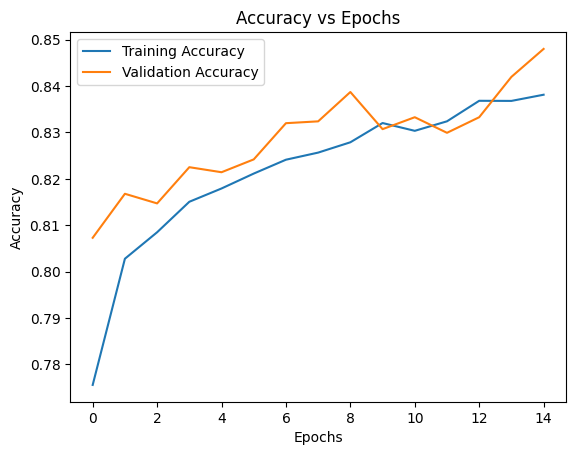

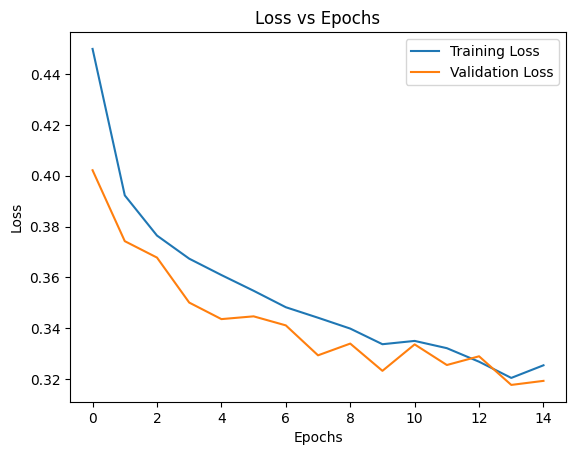

In [27]:
plot_history(results)

Confusion matrix, without normalization
[[4222  840]
 [ 699 4363]]


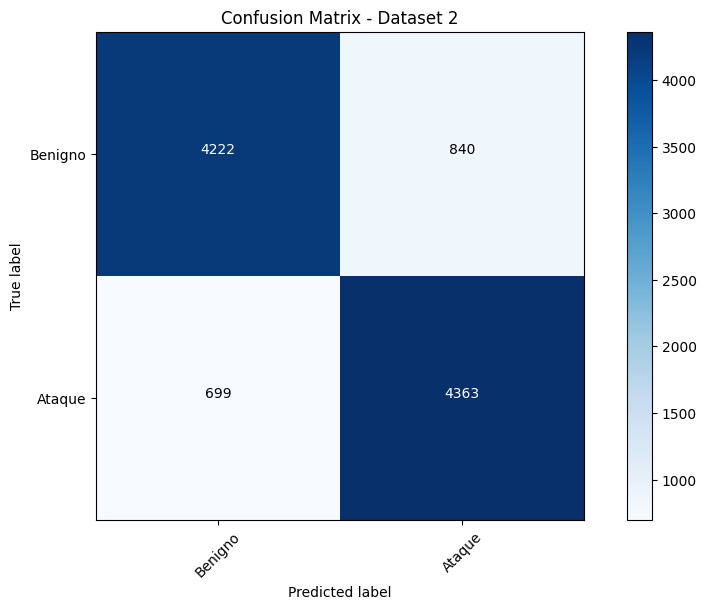

In [28]:
# Generate the confusion matrix
cm = confusion_matrix(y2_test, predictions, labels=np.unique(y2_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Dataset 2')

### Treino no Dataset 3

In [29]:
model3 = cria_modelo(x3_train_scaled.shape[1], pQtdNeurons=8)

## 5. Treino
print("Starting model3 training...")

fp3='./checkpoints/3-cnn-bestmodel.keras'

mc_acc3 = tf.keras.callbacks.ModelCheckpoint(
    filepath=fp3,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=0)

results = model3.fit(
    x3_train_scaled,
    y3_train,
    epochs=15,          # The number of times to iterate over the entire dataset
    batch_size=64,      # The number of samples per gradient update
    validation_data=(x3_test_scaled, y3_test),
    callbacks=[mc_acc3],
    verbose=1           # Show a progress bar
)
print("Training complete.\n")

## 6. Evaluate the Model
print("Evaluating model performance on the test set...")
# Get the final loss and accuracy on the test data
loss, accuracy = model3.evaluate(x3_test_scaled, y3_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model3.predict(x3_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y3_test, predictions, target_names=attack_categories, labels=np.unique(y3_test)))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,010 (43.01 KB)

 Trainable params: 11,010 (43.01 KB)

 Non-trainable params: 0 (0.00 B)

Modelo criado com 256 neurônios.

Compilando modelo...
Compilação completa.

Starting model3 training...
Epoch 1/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9490 - loss: 0.1752 - val_accuracy: 0.9690 - val_loss: 0.1004
Epoch 2/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9692 - loss: 0.0993 - val_accuracy: 0.9703 - val_loss: 0.0909
Epoch 3/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9712 - loss: 0.0875 - val_accuracy: 0.9722 - val_loss: 0.0847
Epoch 4/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9721 - loss: 0.0861 - val_accuracy: 0.9741 - val_loss: 0.0791
Epoch 5/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9740 - loss: 0.0778 - val_accuracy: 0.9731 - val_loss: 0.0823
Epoch 6/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9737 - loss: 0.0785 - val_accuracy: 0.9747 - val_loss: 0.0772
Epoch 7/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.0753 - val_accuracy: 0.9752 - val_loss: 0.0737

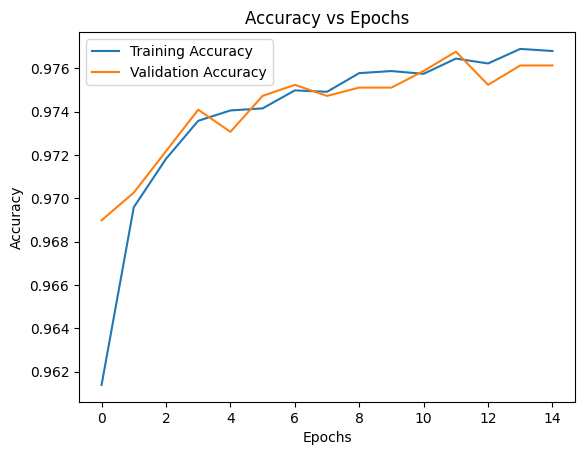

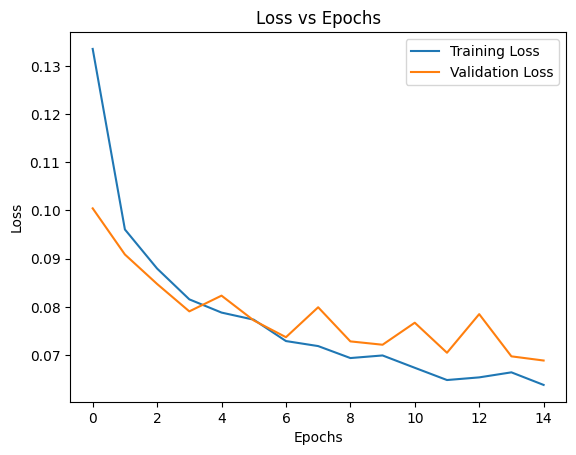

In [30]:
plot_history(results)

Confusion matrix, without normalization
[[1758  179]
 [   8 5889]]


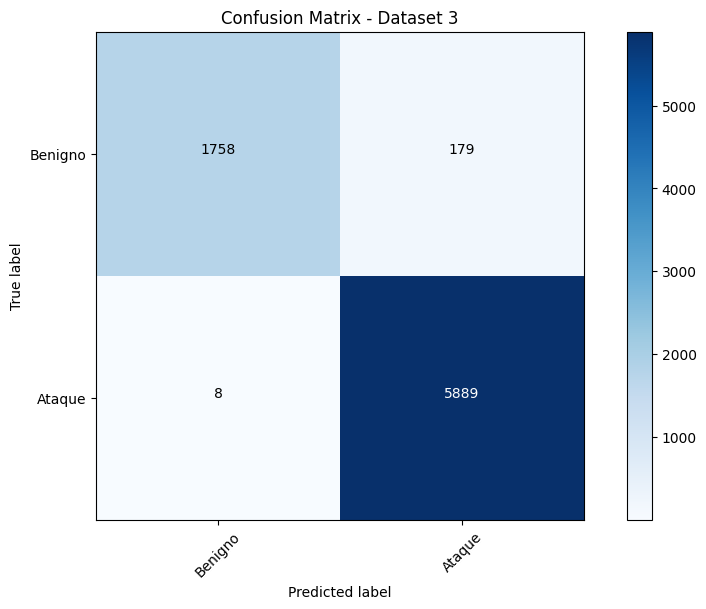

In [31]:
# Generate the confusion matrix
cm = confusion_matrix(y3_test, predictions, labels=np.unique(y3_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Dataset 3')

### Treino no Dataset 4

In [32]:
model4 = cria_modelo(x4_train_scaled.shape[1], pQtdNeurons=8)

## 5. Treino
print("Starting model4 training...")

fp4='./checkpoints/4-cnn-bestmodel.keras'

mc_acc4 = tf.keras.callbacks.ModelCheckpoint(
    filepath=fp4,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=0)

results = model4.fit(
    x4_train_scaled,
    y4_train,
    epochs=15,          # The number of times to iterate over the entire dataset
    batch_size=64,      # The number of samples per gradient update
    validation_data=(x4_test_scaled, y4_test),
    callbacks=[mc_acc4],
    verbose=1           # Show a progress bar
)
print("Training complete.\n")

## 6. Evaluate the Model
print("Evaluating model performance on the test set...")
# Get the final loss and accuracy on the test data
loss, accuracy = model4.evaluate(x4_test_scaled, y4_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model4.predict(x4_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y4_test, predictions, target_names=attack_categories, labels=np.unique(y4_test)))

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,010 (43.01 KB)

 Trainable params: 11,010 (43.01 KB)

 Non-trainable params: 0 (0.00 B)

Modelo criado com 256 neurônios.

Compilando modelo...
Compilação completa.

Starting model3 training...
Epoch 1/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8740 - loss: 0.3128 - val_accuracy: 0.9393 - val_loss: 0.1901
Epoch 2/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9451 - loss: 0.1692 - val_accuracy: 0.9438 - val_loss: 0.1683
Epoch 3/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9456 - loss: 0.1643 - val_accuracy: 0.9474 - val_loss: 0.1657
Epoch 4/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9475 - loss: 0.1604 - val_accuracy: 0.9489 - val_loss: 0.1585
Epoch 5/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9502 - loss: 0.1542 - val_accuracy: 0.9423 - val_loss: 0.1565
Epoch 6/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9513 - loss: 0.1503 - val_accuracy: 0.9486 - val_loss: 0.1536
Epoch 7/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9515 - loss: 0.1481 - val_accuracy: 0.9488 - val_loss: 0.1515

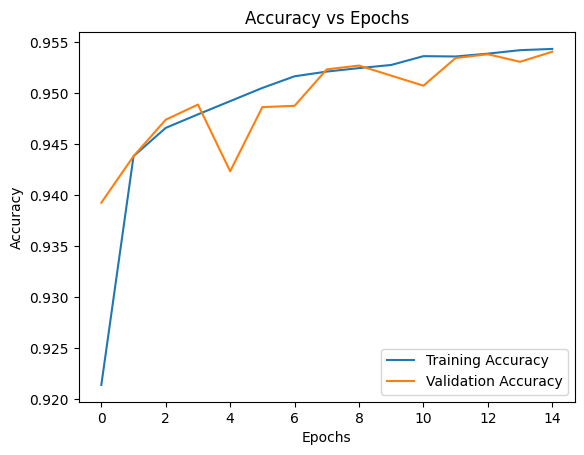

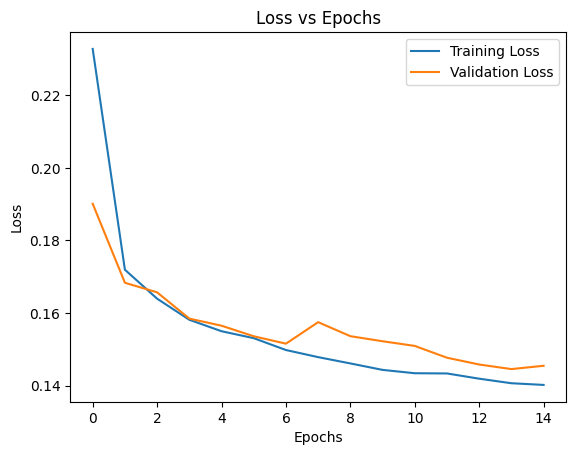

In [33]:
plot_history(results)

Confusion matrix, without normalization
[[4775   50]
 [ 322 2952]]


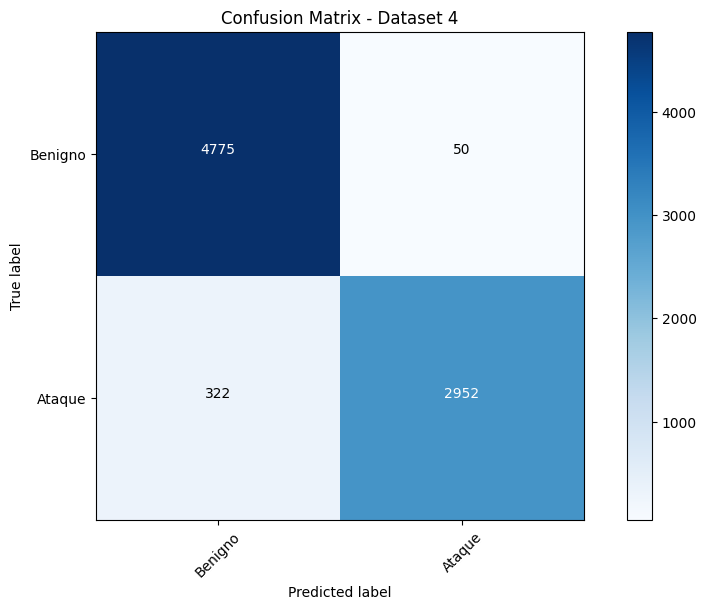

In [34]:
# Generate the confusion matrix
cm = confusion_matrix(y4_test, predictions, labels=np.unique(y4_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Dataset 4')

### Treino no Dataset 5 (2+3+4)

In [35]:
model5 = cria_modelo(x5_train_scaled.shape[1], pQtdNeurons=8)

## Treino
print("Starting model5 training...")

fp5='./checkpoints/5-cnn-bestmodel.keras'

mc_acc5 = tf.keras.callbacks.ModelCheckpoint(
    filepath=fp5,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=0)

results = model5.fit(
    x5_train_scaled,
    y5_train,
    epochs=15,          # The number of times to iterate over the entire dataset
    batch_size=64,      # The number of samples per gradient update
    validation_data=(x5_test_scaled, y5_test),
    callbacks=[mc_acc5],
    verbose=1           # Show a progress bar
)
print("Training complete.\n")

## Evaluate the Model
print("Evaluating model performance on the test set...")
# Get the final loss and accuracy on the test data
loss, accuracy = model5.evaluate(x5_test_scaled, y5_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model5.predict(x5_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y5_test, predictions, target_names=attack_categories, labels=np.unique(y5_test)))

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,010 (43.01 KB)

 Trainable params: 11,010 (43.01 KB)

 Non-trainable params: 0 (0.00 B)

Modelo criado com 256 neurônios.

Compilando modelo...
Compilação completa.

Starting model5 training...
Epoch 1/15
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7966 - loss: 0.4233 - val_accuracy: 0.8507 - val_loss: 0.3160
Epoch 2/15
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8620 - loss: 0.3089 - val_accuracy: 0.8793 - val_loss: 0.2886
Epoch 3/15
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8727 - loss: 0.2893 - val_accuracy: 0.8646 - val_loss: 0.2788
Epoch 4/15
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8776 - loss: 0.2811 - val_accuracy: 0.8831 - val_loss: 0.2738
Epoch 5/15
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8773 - loss: 0.2792 - val_accuracy: 0.8868 - val_loss: 0.2667
Epoch 6/15
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8809 - loss: 0.2712 - val_accuracy: 0.8808 - val_loss: 0.2692
Epoch 7/15
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8847 - loss: 0.2689 - val_accuracy: 0.8868 - va

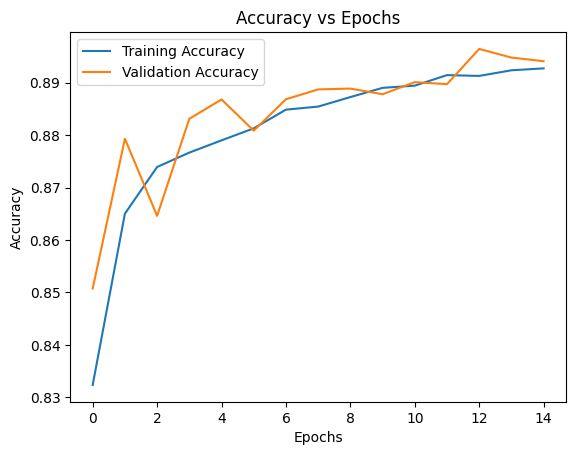

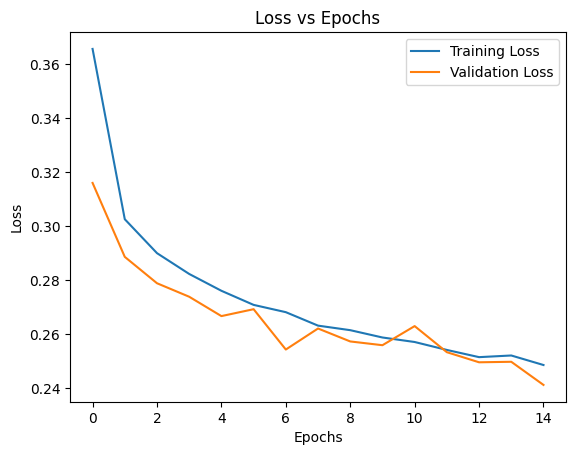

In [36]:
plot_history(results)

Confusion matrix, without normalization
[[10048  1775]
 [  985 13248]]


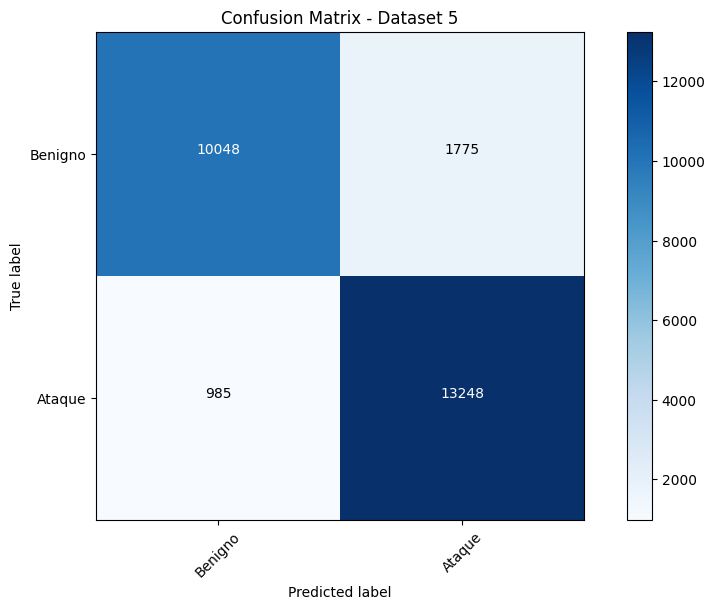

In [37]:
# Generate the confusion matrix
cm = confusion_matrix(y5_test, predictions, labels=np.unique(y5_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Dataset 5')

## Crossdataset

### Modelo treinado no 2, testando no 3, no 4 e no 5

In [38]:
print(" ######## USANDO O MODELO TREINADO NO DATASET 2 ########")

 ######## USANDO O MODELO TREINADO NO DATASET 2 ########


#### Testando no 3

In [39]:
## Evaluate the Model
print("Evaluating model performance on the test set DS3...")
# Get the final loss and accuracy on the test data
loss, accuracy = model2.evaluate(x3_test_scaled, y3_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model2.predict(x3_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y3_test, predictions, target_names=attack_categories, labels=np.unique(y3_test)))

Evaluating model performance on the test set DS3...
Test Accuracy: 0.2901
Test Loss: 3.1613

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.24      0.87      0.38      1937
      Ataque       0.70      0.10      0.17      5897

    accuracy                           0.29      7834
   macro avg       0.47      0.49      0.28      7834
weighted avg       0.59      0.29      0.22      7834



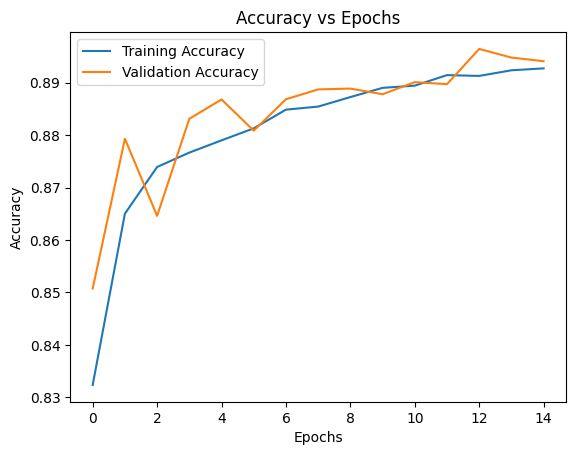

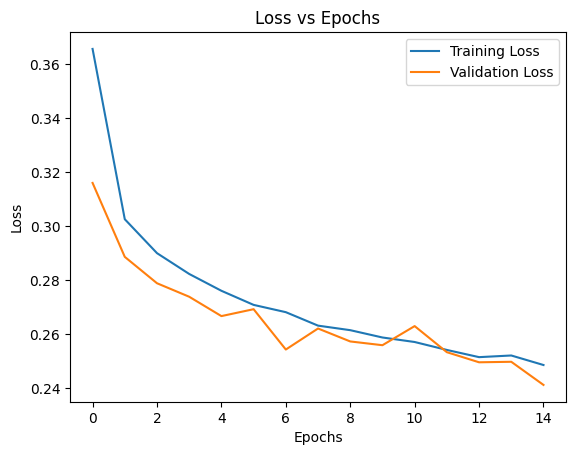

In [40]:
plot_history(results)

Confusion matrix, without normalization
[[1692  245]
 [5316  581]]


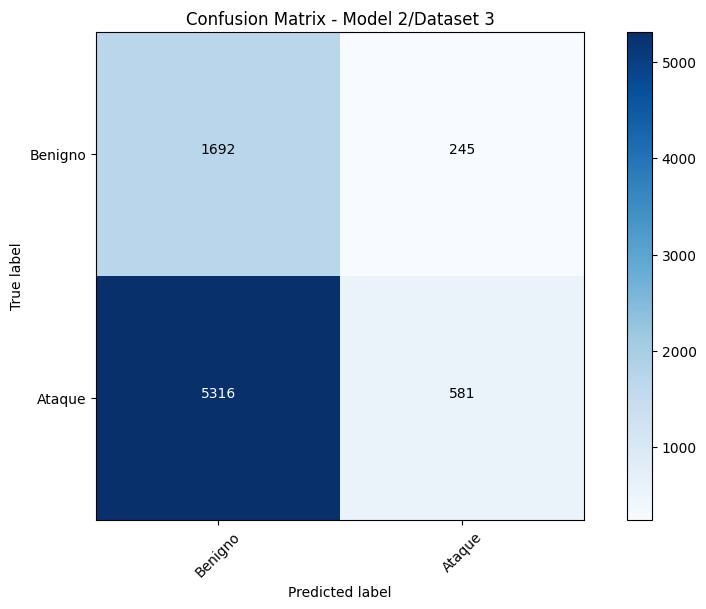

In [41]:
# Generate the confusion matrix
cm = confusion_matrix(y3_test, predictions, labels=np.unique(y3_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 2/Dataset 3')

#### Testando no 4

In [42]:
## Evaluate the Model
print("Evaluating model performance on the test set DS4...")
# Get the final loss and accuracy on the test data
loss, accuracy = model2.evaluate(x4_test_scaled, y4_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model2.predict(x4_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y4_test, predictions, target_names=attack_categories, labels=np.unique(y4_test)))

Evaluating model performance on the test set DS4...
Test Accuracy: 0.4213
Test Loss: 6.2702

254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.51      0.60      0.55      4825
      Ataque       0.21      0.16      0.18      3274

    accuracy                           0.42      8099
   macro avg       0.36      0.38      0.37      8099
weighted avg       0.39      0.42      0.40      8099



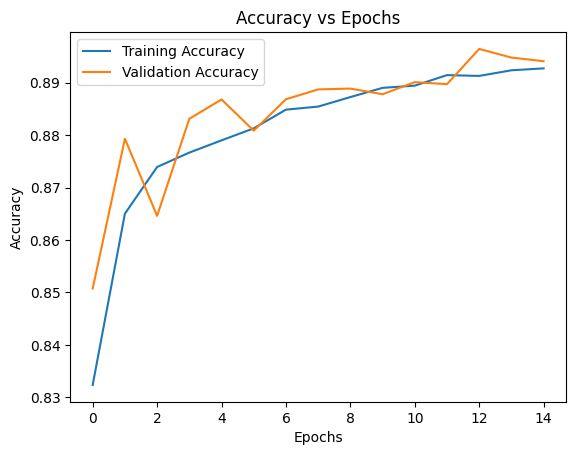

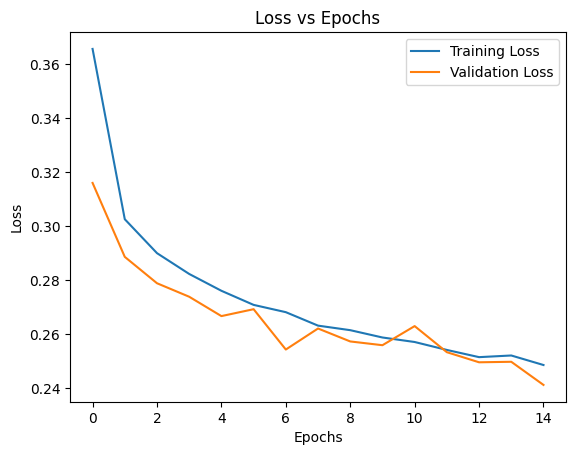

In [43]:
plot_history(results)

Confusion matrix, without normalization
[[2882 1943]
 [2744  530]]


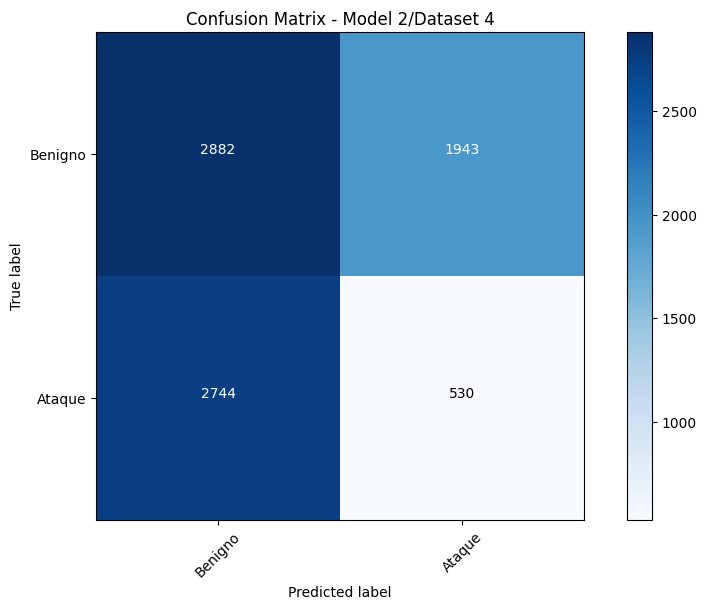

In [44]:
# Generate the confusion matrix
cm = confusion_matrix(y4_test, predictions, labels=np.unique(y4_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 2/Dataset 4')

#### Testando no 5

In [45]:
## Evaluate the Model
print("Evaluating model performance on the test set DS5...")
# Get the final loss and accuracy on the test data
loss, accuracy = model2.evaluate(x5_test_scaled, y5_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model2.predict(x5_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y5_test, predictions, target_names=attack_categories, labels=np.unique(y5_test)))

Evaluating model performance on the test set DS5...
Test Accuracy: 0.5173
Test Loss: 1.9572

815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.48      0.76      0.59     11823
      Ataque       0.61      0.31      0.42     14233

    accuracy                           0.52     26056
   macro avg       0.55      0.54      0.50     26056
weighted avg       0.55      0.52      0.49     26056



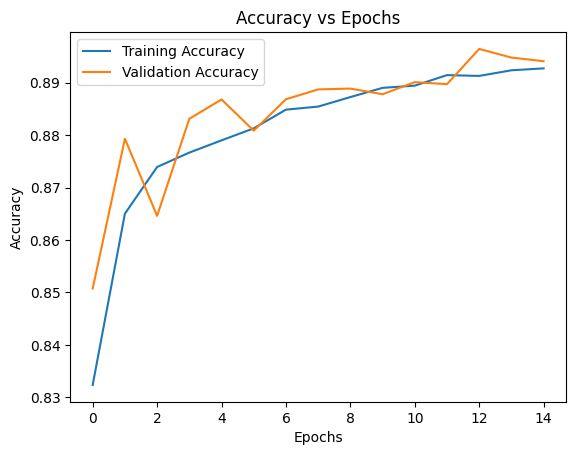

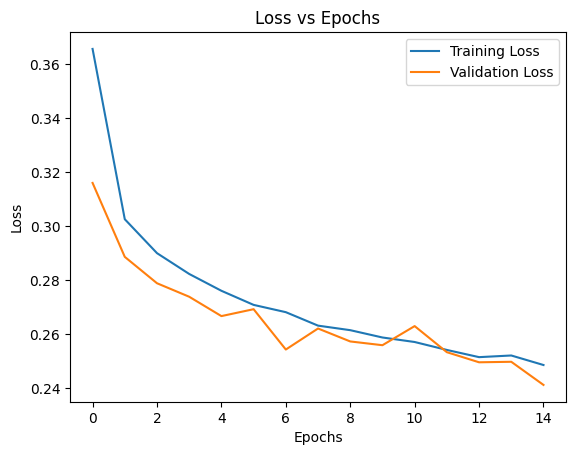

In [46]:
plot_history(results)

Confusion matrix, without normalization
[[9011 2812]
 [9766 4467]]


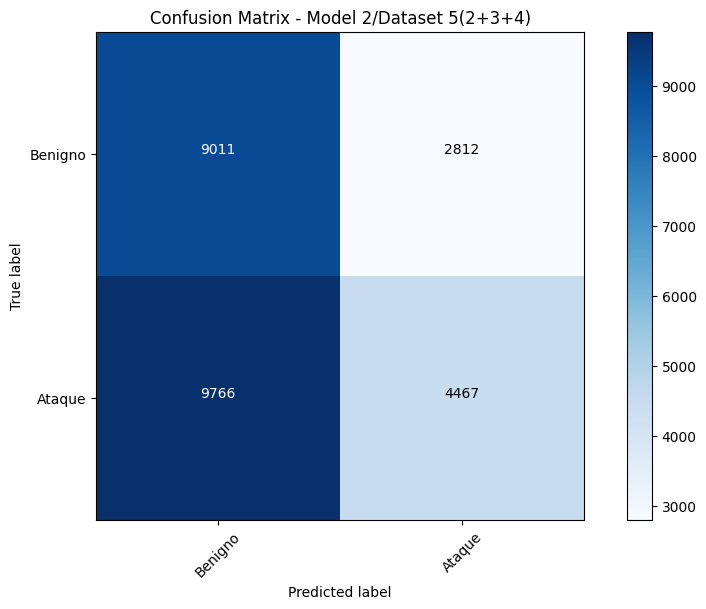

In [47]:
# Generate the confusion matrix
cm = confusion_matrix(y5_test, predictions, labels=np.unique(y5_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 2/Dataset 5(2+3+4)')

### Modelo treinado no 3, testando no 2, no 4 e no 5

In [48]:
print(" ######## USANDO O MODELO TREINADO NO DATASET 3 ########")

 ######## USANDO O MODELO TREINADO NO DATASET 3 ########


#### Testando no 2

In [49]:
## Evaluate the Model
print("Evaluating model performance on the test set DS2...")
# Get the final loss and accuracy on the test data
loss, accuracy = model3.evaluate(x2_test_scaled, y2_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model3.predict(x2_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y2_test, predictions, target_names=attack_categories, labels=np.unique(y2_test)))

Evaluating model performance on the test set DS2...
Test Accuracy: 0.4918
Test Loss: 4.0718

317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.48      0.18      0.26      5062
      Ataque       0.49      0.80      0.61      5062

    accuracy                           0.49     10124
   macro avg       0.49      0.49      0.44     10124
weighted avg       0.49      0.49      0.44     10124



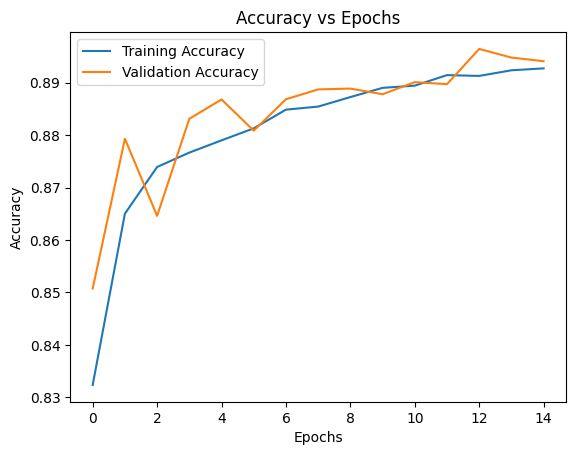

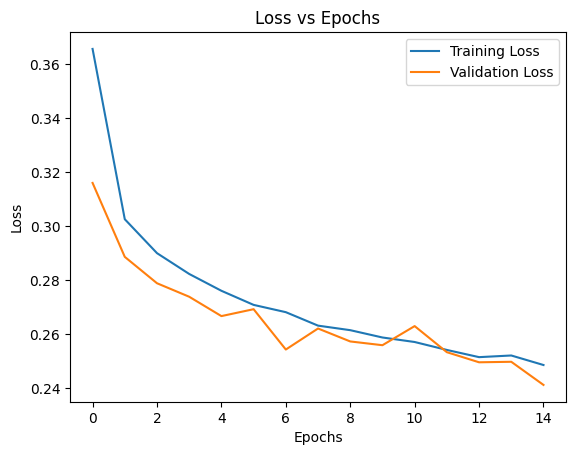

In [50]:
plot_history(results)

Confusion matrix, without normalization
[[ 921 4141]
 [1004 4058]]


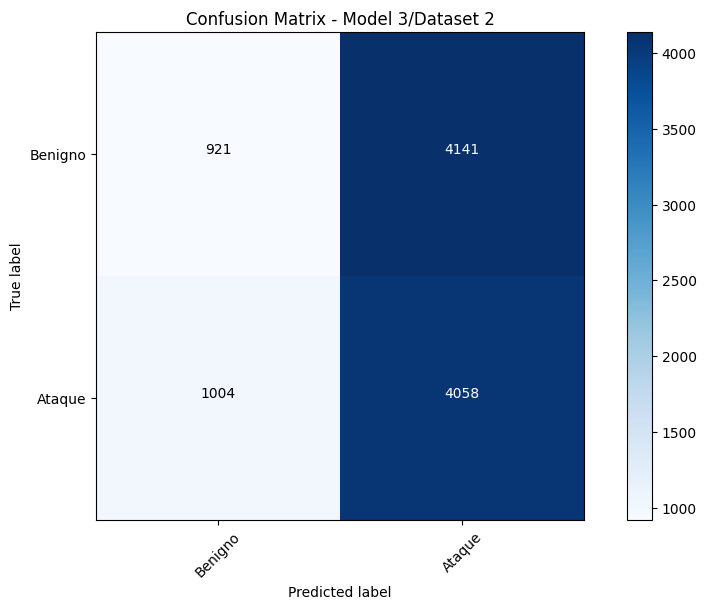

In [51]:
# Generate the confusion matrix
cm = confusion_matrix(y2_test, predictions, labels=np.unique(y2_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 3/Dataset 2')

#### Testando no 4

In [52]:
## Evaluate the Model
print("Evaluating model performance on the test set DS4...")
# Get the final loss and accuracy on the test data
loss, accuracy = model3.evaluate(x4_test_scaled, y4_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model3.predict(x4_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y4_test, predictions, target_names=attack_categories, labels=np.unique(y4_test)))

Evaluating model performance on the test set DS4...
Test Accuracy: 0.5482
Test Loss: 4.7512

254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.65      0.52      0.58      4825
      Ataque       0.46      0.60      0.52      3274

    accuracy                           0.55      8099
   macro avg       0.55      0.56      0.55      8099
weighted avg       0.57      0.55      0.55      8099



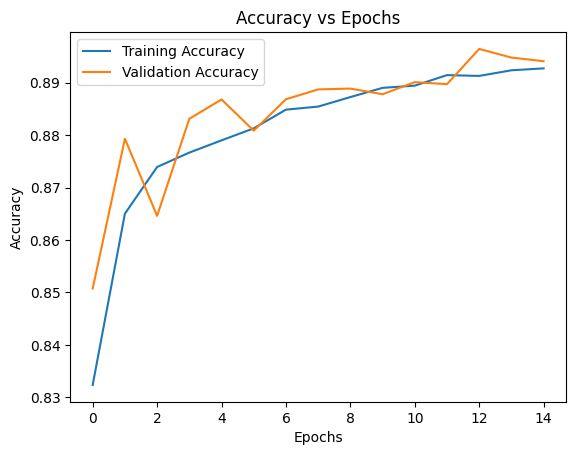

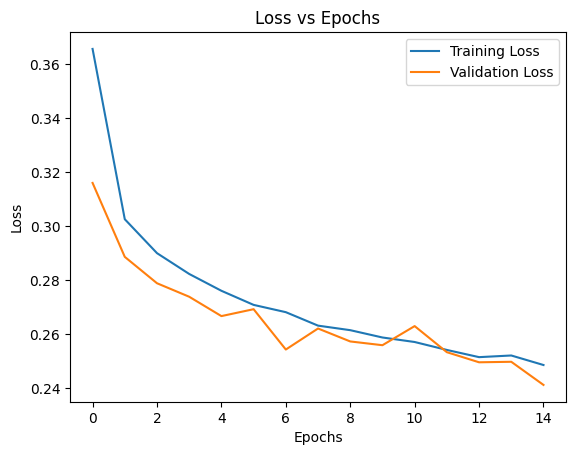

In [53]:
plot_history(results)

Confusion matrix, without normalization
[[2488 2337]
 [1322 1952]]


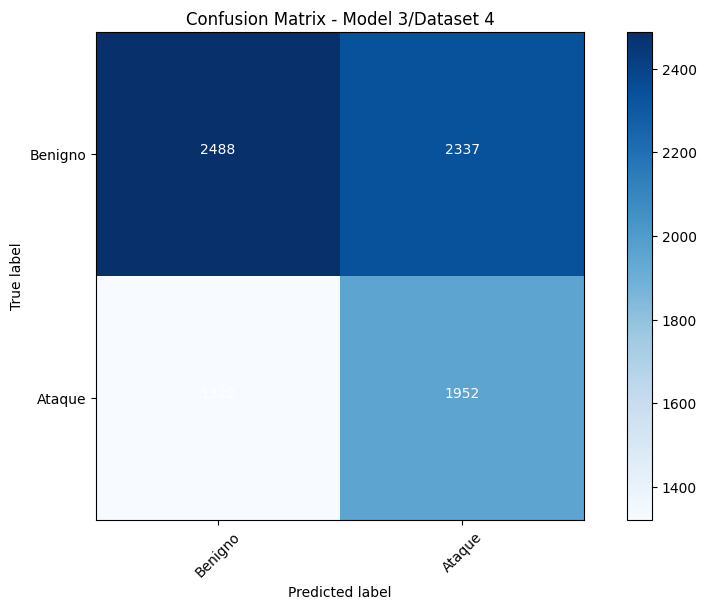

In [54]:
# Generate the confusion matrix
cm = confusion_matrix(y4_test, predictions, labels=np.unique(y4_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 3/Dataset 4')

#### Testando no 5

In [55]:
## Evaluate the Model
print("Evaluating model performance on the test set DS5...")
# Get the final loss and accuracy on the test data
loss, accuracy = model3.evaluate(x5_test_scaled, y5_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model3.predict(x5_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y5_test, predictions, target_names=attack_categories, labels=np.unique(y5_test)))

Evaluating model performance on the test set DS5...
Test Accuracy: 0.6235
Test Loss: 2.3509

815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 675us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.63      0.41      0.49     11823
      Ataque       0.62      0.80      0.70     14233

    accuracy                           0.62     26056
   macro avg       0.63      0.61      0.60     26056
weighted avg       0.63      0.62      0.61     26056



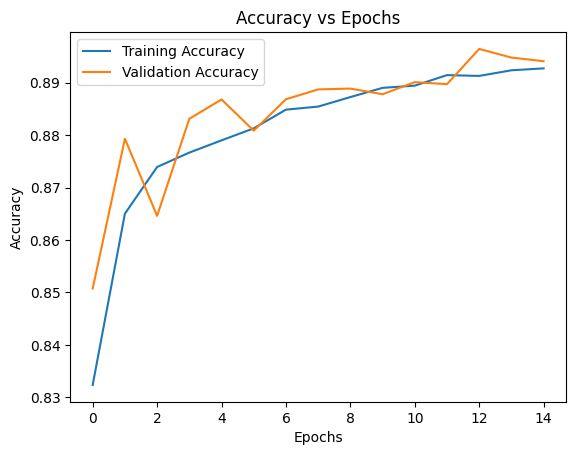

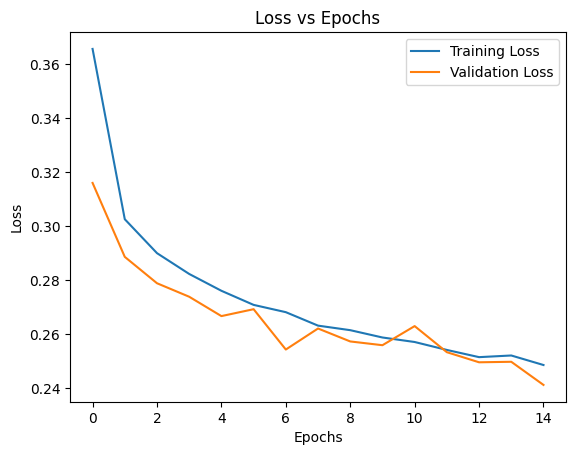

In [56]:
plot_history(results)

Confusion matrix, without normalization
[[ 4801  7022]
 [ 2789 11444]]


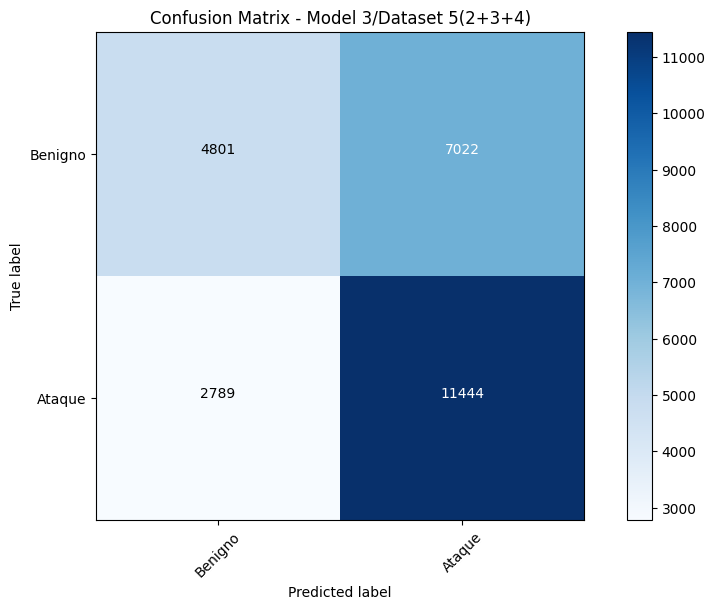

In [57]:
# Generate the confusion matrix
cm = confusion_matrix(y5_test, predictions, labels=np.unique(y5_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 3/Dataset 5(2+3+4)')

### Modelo treinado no 4, testando no 2, no 3 e no 5

In [58]:
print(" ######## USANDO O MODELO TREINADO NO DATASET 4 ########")

 ######## USANDO O MODELO TREINADO NO DATASET 4 ########


#### Testando no 2

In [59]:
## Evaluate the Model
print("Evaluating model performance on the test set DS2...")
# Get the final loss and accuracy on the test data
loss, accuracy = model4.evaluate(x2_test_scaled, y2_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model4.predict(x2_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y2_test, predictions, target_names=attack_categories, labels=np.unique(y2_test)))

Evaluating model performance on the test set DS2...
Test Accuracy: 0.5162
Test Loss: 1.5228

317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.51      0.75      0.61      5062
      Ataque       0.53      0.28      0.37      5062

    accuracy                           0.52     10124
   macro avg       0.52      0.52      0.49     10124
weighted avg       0.52      0.52      0.49     10124



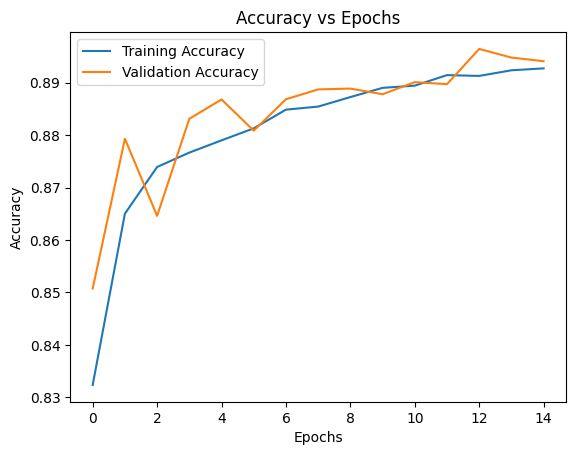

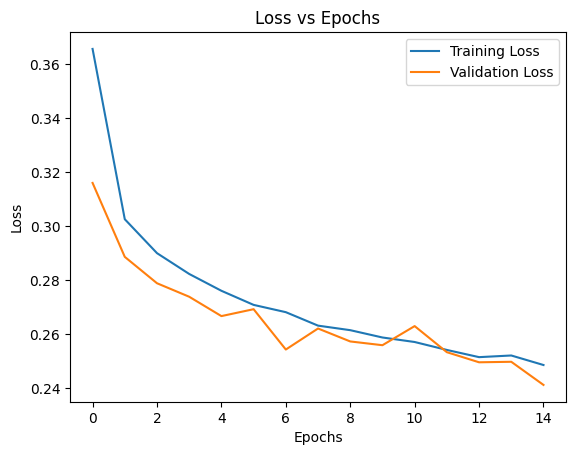

In [60]:
plot_history(results)

Confusion matrix, without normalization
[[3814 1248]
 [3650 1412]]


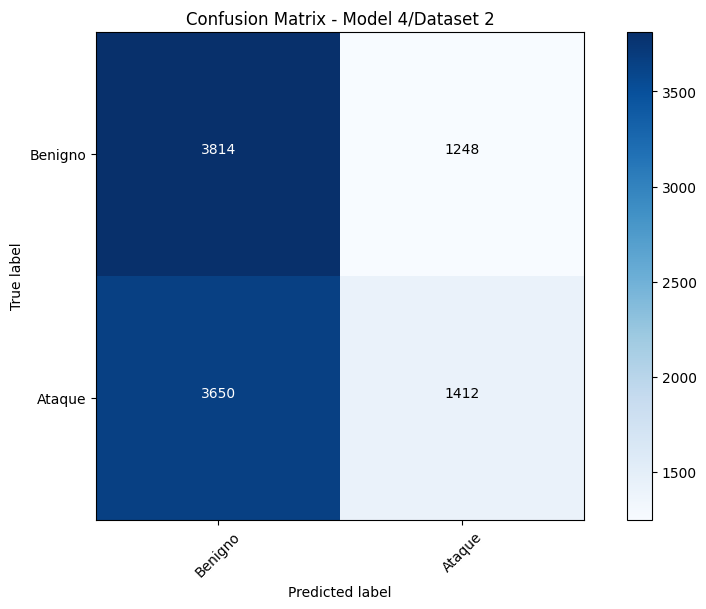

In [61]:
# Generate the confusion matrix
cm = confusion_matrix(y2_test, predictions, labels=np.unique(y2_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 4/Dataset 2')

#### Testando no 3

In [62]:
## Evaluate the Model
print("Evaluating model performance on the test set DS3...")
# Get the final loss and accuracy on the test data
loss, accuracy = model4.evaluate(x3_test_scaled, y3_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model4.predict(x3_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y3_test, predictions, target_names=attack_categories, labels=np.unique(y3_test)))

Evaluating model performance on the test set DS3...
Test Accuracy: 0.2309
Test Loss: 3.8605

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.13      0.38      0.19      1937
      Ataque       0.47      0.18      0.26      5897

    accuracy                           0.23      7834
   macro avg       0.30      0.28      0.23      7834
weighted avg       0.39      0.23      0.25      7834



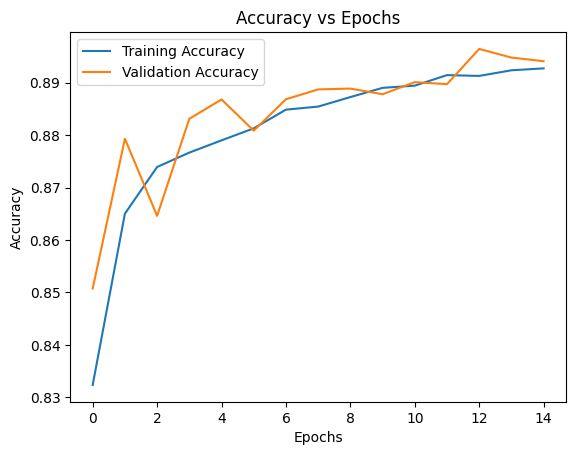

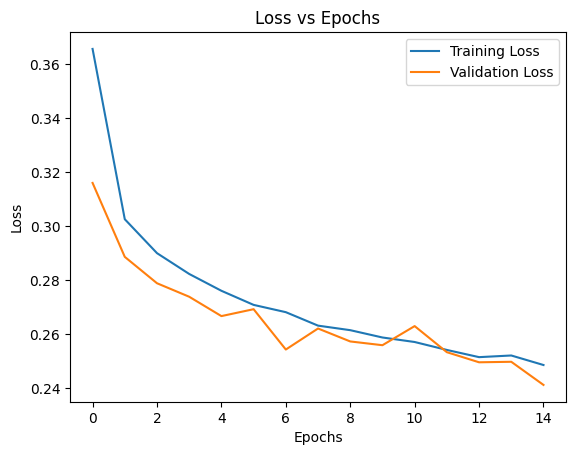

In [63]:
plot_history(results)

Confusion matrix, without normalization
[[ 727 1210]
 [4815 1082]]


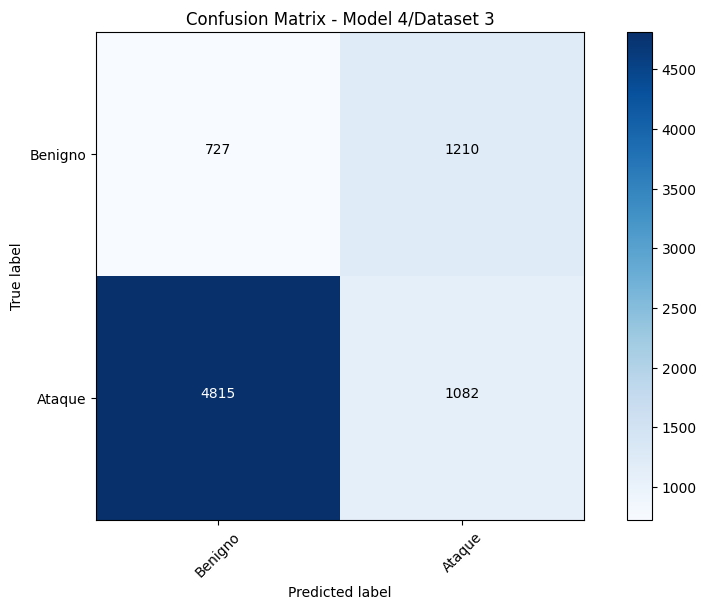

In [64]:
# Generate the confusion matrix
cm = confusion_matrix(y3_test, predictions, labels=np.unique(y3_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 4/Dataset 3')

#### Testando no 5

In [65]:
## Evaluate the Model
print("Evaluating model performance on the test set DS5...")
# Get the final loss and accuracy on the test data
loss, accuracy = model4.evaluate(x5_test_scaled, y5_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model4.predict(x5_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y5_test, predictions, target_names=attack_categories, labels=np.unique(y5_test)))

Evaluating model performance on the test set DS5...
Test Accuracy: 0.4893
Test Loss: 1.8545

815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.47      0.88      0.61     11823
      Ataque       0.62      0.17      0.26     14233

    accuracy                           0.49     26056
   macro avg       0.54      0.52      0.44     26056
weighted avg       0.55      0.49      0.42     26056



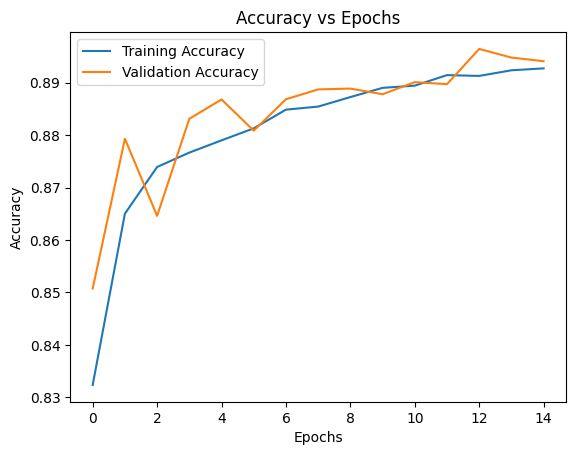

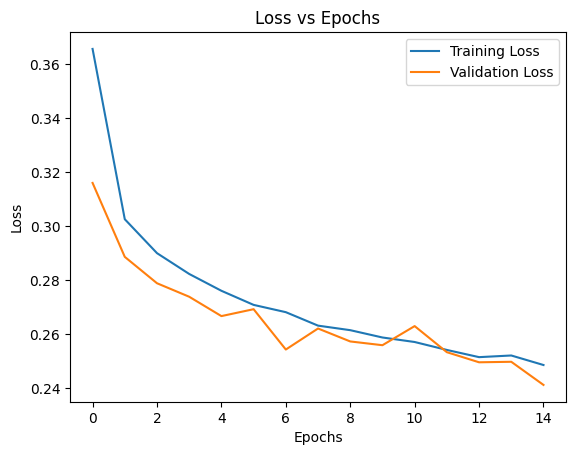

In [66]:
plot_history(results)

Confusion matrix, without normalization
[[10353  1470]
 [11837  2396]]


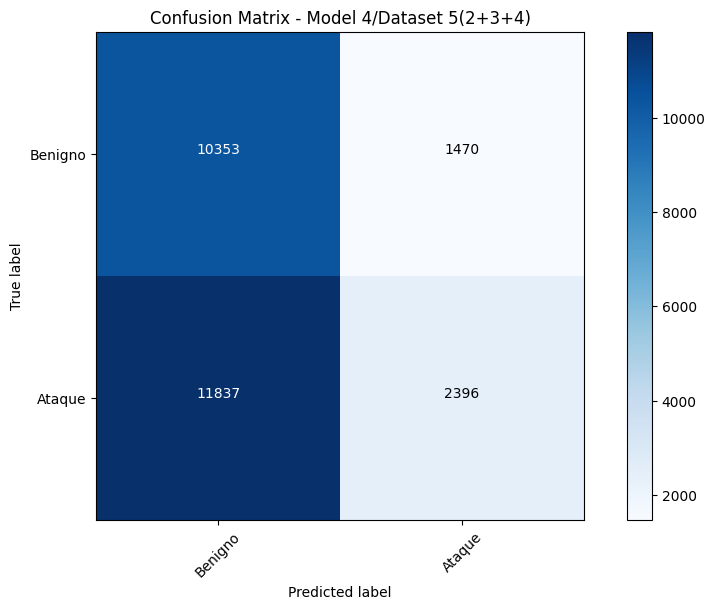

In [67]:
# Generate the confusion matrix
cm = confusion_matrix(y5_test, predictions, labels=np.unique(y5_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 4/Dataset 5(2+3+4)')

### Modelo treinado no 5, testando no 2, no 3 e no 4

In [68]:
print(" ######## USANDO O MODELO TREINADO NO DATASET 5 ########")

 ######## USANDO O MODELO TREINADO NO DATASET 5 ########


#### Testando no 2

In [69]:
## Evaluate the Model
print("Evaluating model performance on the test set DS2...")
# Get the final loss and accuracy on the test data
loss, accuracy = model5.evaluate(x2_test_scaled, y2_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model5.predict(x2_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y2_test, predictions, target_names=attack_categories, labels=np.unique(y2_test)))

Evaluating model performance on the test set DS2...
Test Accuracy: 0.7254
Test Loss: 1.1562

317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.76      0.66      0.71      5062
      Ataque       0.70      0.79      0.74      5062

    accuracy                           0.73     10124
   macro avg       0.73      0.73      0.72     10124
weighted avg       0.73      0.73      0.72     10124



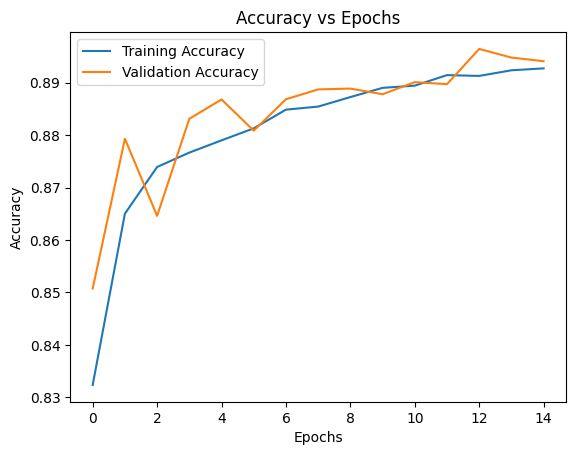

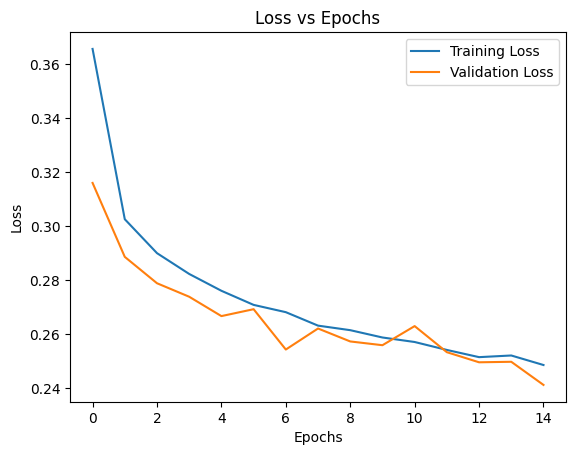

In [70]:
plot_history(results)

Confusion matrix, without normalization
[[3328 1734]
 [1046 4016]]


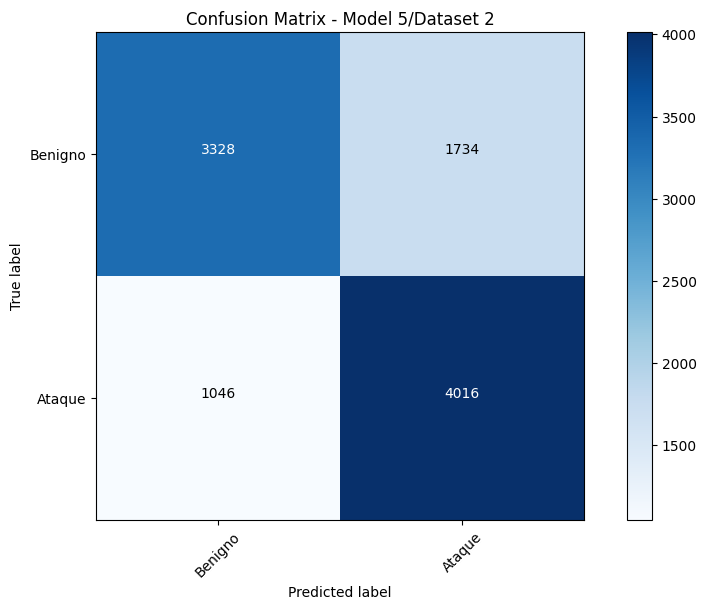

In [71]:
# Generate the confusion matrix
cm = confusion_matrix(y2_test, predictions, labels=np.unique(y2_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 5/Dataset 2')

#### Testando no 3

In [72]:
## Evaluate the Model
print("Evaluating model performance on the test set DS3...")
# Get the final loss and accuracy on the test data
loss, accuracy = model5.evaluate(x3_test_scaled, y3_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model5.predict(x3_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y3_test, predictions, target_names=attack_categories, labels=np.unique(y3_test)))

Evaluating model performance on the test set DS3...
Test Accuracy: 0.8189
Test Loss: 0.4401

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.59      0.91      0.71      1937
      Ataque       0.96      0.79      0.87      5897

    accuracy                           0.82      7834
   macro avg       0.77      0.85      0.79      7834
weighted avg       0.87      0.82      0.83      7834



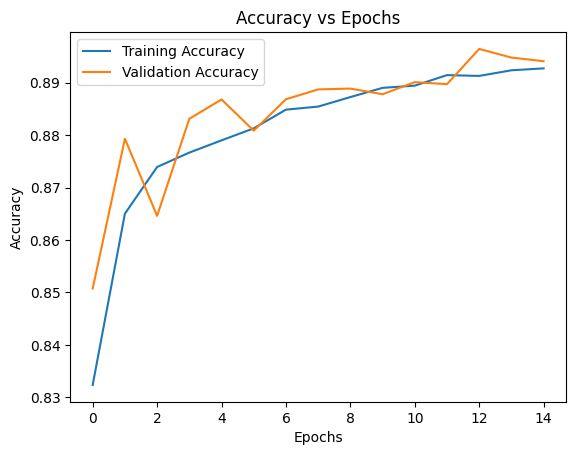

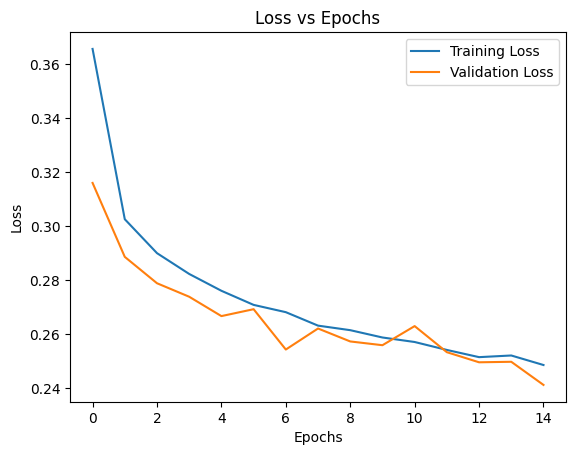

In [73]:
plot_history(results)

Confusion matrix, without normalization
[[1759  178]
 [1241 4656]]


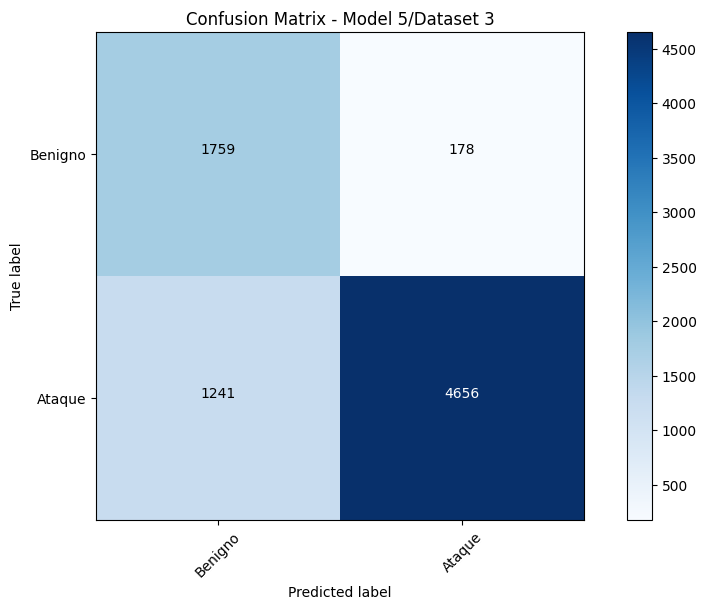

In [74]:
# Generate the confusion matrix
cm = confusion_matrix(y3_test, predictions, labels=np.unique(y3_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 5/Dataset 3')

#### Testando no 4

In [75]:
## Evaluate the Model
print("Evaluating model performance on the test set DS4...")
# Get the final loss and accuracy on the test data
loss, accuracy = model5.evaluate(x4_test_scaled, y4_test, verbose=0) # Use original integer labels for evaluation
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}\n")

# Make predictions to generate a classification report
predictions_prob = model5.predict(x4_test_scaled)
# Convert probabilities to predicted class labels (index with highest probability)
predictions = np.argmax(predictions_prob, axis=1)

print("Classification Report:")
print(classification_report(y4_test, predictions, target_names=attack_categories, labels=np.unique(y4_test)))

Evaluating model performance on the test set DS4...
Test Accuracy: 0.5312
Test Loss: 4.6217

254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step
Classification Report:
              precision    recall  f1-score   support

     Benigno       0.62      0.56      0.59      4825
      Ataque       0.43      0.49      0.46      3274

    accuracy                           0.53      8099
   macro avg       0.52      0.52      0.52      8099
weighted avg       0.54      0.53      0.53      8099



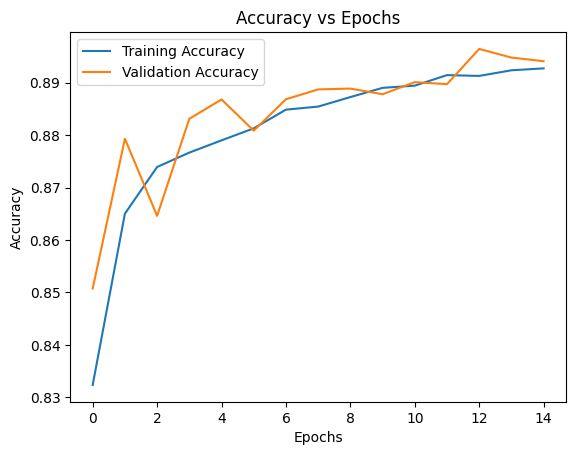

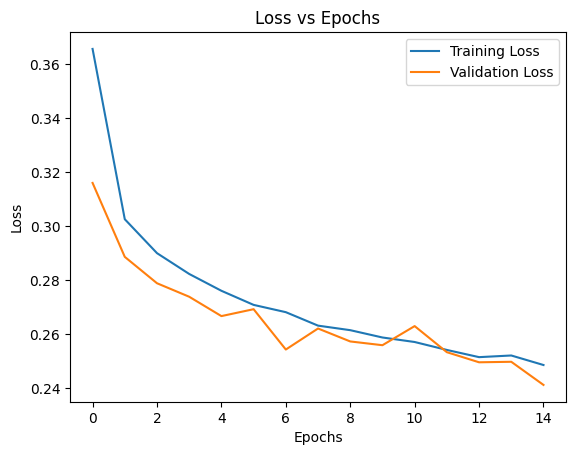

In [76]:
plot_history(results)

Confusion matrix, without normalization
[[2701 2124]
 [1673 1601]]


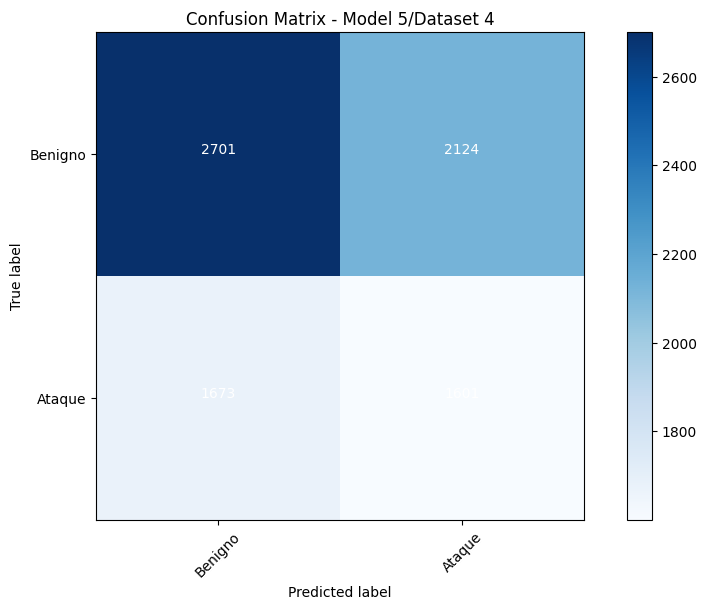

In [77]:
# Generate the confusion matrix
cm = confusion_matrix(y4_test, predictions, labels=np.unique(y4_test))

# Plot the confusion matrix
plot_confusion_matrix(cm, classes=attack_categories, title='Confusion Matrix - Model 5/Dataset 4')

# MultiObjetivo

In [78]:
!pip install -U pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.8/303.8 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.1 MB/s eta 0:00:00


In [79]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.core.problem import Problem
from pymoo.core.sampling import Sampling

from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.core.problem import ElementwiseProblem
from pymoo.core.callback import Callback

import os
import pickle


In [80]:
! pip show tensorflow
! pip show scikit-learn
! pip show pymoo
! python --version

Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras
Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:



In [81]:
#isto significa uma quantidade de
print(f"Quantidade de possibilidades de qualquer número de features: {2**len(X2.columns):,}")
print(f"Quantidade de possibilidades de 40 features pegando 17 a cada vez: {math.comb(40, 17):,}")
print(f"Quantidade de possibilidades de 40 features pegando 05 a cada vez: {math.comb(40,  5):,}")
print(f"Quantidade de possibilidades de 40 features pegando 03 a cada vez: {math.comb(40,  3):,}")

Quantidade de possibilidades de qualquer número de features: 1,099,511,627,776
Quantidade de possibilidades de 40 features pegando 17 a cada vez: 88,732,378,800
Quantidade de possibilidades de 40 features pegando 05 a cada vez: 658,008
Quantidade de possibilidades de 40 features pegando 03 a cada vez: 9,880


In [87]:
#constantes com a definição dos logs
LOG_DIR = '/content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Resultados/2025-11-01/'
LOG_EXECUCAO = 'exec.txt'
LOG_CHECKPOINT = 'checkpoint.pkl'
LOG_FINAL = 'final.pkl'

In [88]:
# Classe de amostragem customizada para início com uma quantidade menor de features
# Esta classe herda de pymoo.core.sampling.Sampling e implementa o método _do.
class SamplingComFeaturesFixas(Sampling):

    def __init__(self, n_features_para_selecionar=5):
        """
        Construtor da classe.

        Args:
            n_features_para_selecionar (int): O número exato de features que cada indivíduo
                                              na população inicial deve ter.
        """
        super().__init__()
        self.n_features_para_selecionar = n_features_para_selecionar

    def _do(self, problem, n_samples, **kwargs):
        """
        Este é o método principal que o pymoo chama para criar a população inicial.

        Args:
            problem: O objeto do problema que está sendo resolvido.
            n_samples (int): O tamanho da população (pop_size) a ser criada.

        Returns:
            np.ndarray: Uma matriz de formato (n_samples, n_var) onde as primeiras
                        n_var-1 colunas representam a seleção de features (0 ou 1)
                        e a última coluna representa o número de neurônios.
        """
        # Obtém o número total de variáveis (features + neurônios) do problema. No seu caso, 41.
        n_var = problem.n_var

        # O número de features é n_var - 1
        n_features = n_var - 1

        # Verifica se o número de features a selecionar não é maior que o total de features
        if self.n_features_para_selecionar > n_features:
            raise ValueError("O número de features a selecionar não pode ser maior que o número total de features.")

        # Cria uma matriz de zeros com o formato (tamanho_da_populacao, n_total_de_features)
        # Usamos o tipo float para acomodar a seleção de features (0 ou 1) e o número de neurônios.
        X = np.zeros((n_samples, n_var), dtype=float)

        # Para cada indivíduo (linha) na nossa população inicial...
        for i in range(n_samples):
            # Escolhe aleatoriamente `n_features_para_selecionar` índices únicos
            # entre 0 e n_features-1. A opção `replace=False` garante que os índices não se repitam.
            indices_selecionados = np.random.choice(n_features, self.n_features_para_selecionar, replace=False)

            # Define como 1 as posições correspondentes a esses índices para indicar a seleção da feature.
            X[i, indices_selecionados] = 1

            # Define um número aleatório de neurônios para a última coluna.
            # O intervalo de neurônios deve estar dentro dos limites definidos em problem.xu[-1]
            X[i, -1] = np.random.randint(2, int(problem.xu[-1]) + 1) # Garante ao menos 2 neurônios

        return X

###############################################################################################
# Custom Callback for saving checkpoints
###############################################################################################
class CheckpointCallback(Callback):

    def __init__(self, filename="checkpoint.pkl", verbose=False):
        super().__init__()
        self.filename = filename
        self.verbose = verbose
        self.n_eval = 0

    def notify(self, algorithm):
        # Save the algorithm state
        with open(self.filename, 'wb') as f:
            pickle.dump(algorithm, f)

        if self.verbose:
            print(f"Checkpoint saved at generation {algorithm.n_gen} to {self.filename}")

        # reduz o consumo de memória a cada geração
        gc.collect()
        if self.verbose:
            print(f"Garbage collection completed at generation {algorithm.n_gen}")


def Minimize(problem):

    amostragem_customizada = SamplingComFeaturesFixas(n_features_para_selecionar=3)

    # Define the path for saving and loading the checkpoint
    checkpoint_path = LOG_DIR + LOG_CHECKPOINT

    # Create the checkpoint callback
    checkpoint_callback = CheckpointCallback(filename=checkpoint_path, verbose=True)

    # Check if a checkpoint exists and load it
    if os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from: {checkpoint_path}")

        with open(checkpoint_path, 'rb') as f:
            algorithm = pickle.load(f)
        print(f"Resuming from generation {algorithm.n_gen}")

        #problem.contagem = algorithm.n_gen * algorithm.pop_size

        # Continua otimização
        res = minimize(problem,
                       algorithm, # passa o algoritmo carregado
                       seed=42,   # mantém o mesmo seed original
                       save_history=True,
                       verbose=True,
                       termination=('n_gen', 100),  # continua até o número de gerações chega a 100
                       callback=checkpoint_callback # callback para gravação
                       )
    else:
        print("No checkpoint found. Starting new optimization.")
        # Inicia uma otimização, se não houver checkpoints

        #define o algoritmo
        algorithm = NSGA2(pop_size=100, sampling=amostragem_customizada)

        res = minimize(problem,
                       algorithm,
                       seed=42,
                       save_history=True,
                       verbose=True,
                       termination=('n_gen', 100),
                       callback=checkpoint_callback # callback para gravação
                       )

    # Save the final result
    final_result_path = LOG_DIR + LOG_FINAL
    os.makedirs(os.path.dirname(final_result_path), exist_ok=True)

    with open(final_result_path, 'wb') as f:
        pickle.dump(res, f)
    print(f"Final result saved to: {final_result_path}")


    return res

###############################################################################################
# Classe do problema a ser resolvido
###############################################################################################
class NetFlowProblem(ElementwiseProblem): #ElementWise é orientado a objetos

    def is_to_delete_feature(self, prob):
        return prob < 0.5

    def adjust_features(self, x, X_features):

        delete_indices = [i for i in range(len(x)) if self.is_to_delete_feature(x[i])]

        cols_to_delete = X_features.columns[delete_indices]
        X_features = X_features.drop(columns=cols_to_delete)

        return X_features

    def create_and_train_model(self, pX, py, pQtdNeurons):
        # Separando da base original uma parte para validação. Aqui eu chamarei de teste
        x_train, x_test, y_train, y_test = train_test_split(pX, py, test_size=0.2, random_state=42, stratify=py)

        # normalização
        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        mymodel = cria_modelo(pShape=x_train_scaled.shape[1], pOutput=False, pQtdNeurons=pQtdNeurons)

        mymodel.fit(
          x_train_scaled,
          y_train,
          epochs=15,
          batch_size=64,
          validation_data=(x_test_scaled, y_test),
          #callbacks=[mc_accm], # desativei a callback para aumentar a velocidade. Resultado: não alterou tanto...
          verbose=0             # progress bar
        )

        # Libera a memória dos dados de treino/teste que não são mais necessários
        del x_train, x_test, y_train, y_test, x_train_scaled, x_test_scaled, scaler
        gc.collect()

        return mymodel


    def get_predicted_class(self, pX, py):

        # Separando da base original uma parte para validação. Aqui eu chamarei de teste
        x_train, x_test, y_train, y_test = train_test_split(pX, py, test_size=0.2, random_state=42, stratify=py)

        # normalização
        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        #mymodel = cria_modelo(pShape=x_train_scaled.shape[1], pOutput=False, pQtdNeurons=p_num_neurons)

        #fpm='./checkpoints/mo-cnn-bestmodel.keras'

        #mc_accm = tf.keras.callbacks.ModelCheckpoint(
        #    filepath=fpm,
        #    monitor='val_accuracy',
        #    mode='max',
        #    save_best_only=True,
        #    verbose=0)

        #treino
        #mymodel.fit(
        #  x_train_scaled,
        #  y_train,
        #  epochs=15,
        #  batch_size=64,
        #  validation_data=(x_test_scaled, y_test),
          #callbacks=[mc_accm], # desativei a callback para aumentar a velocidade. Resultado: não alterou tanto...
        #  verbose=0             # progress bar
        #)

        predictions_prob = self.modelAll.predict(x_test_scaled, verbose=0 )
        predictions = np.argmax(predictions_prob, axis=1) # Convert probabilities to predicted class labels

        #marca para o garbage collector remover da memória a fim de conter a expansão do consumo
        del x_train, x_test, y_train, x_train_scaled, x_test_scaled, predictions_prob #, mc_accm, fpm
        gc.collect()


        return predictions, y_test


    def evaluate_model_f1(self,pX
                              ,py
                          ):
        # Executa a predição no conjunto de dados passado (algum dataset de teste)
        y_test_predict, y_test_true = self.get_predicted_class(pX, py)
        # Calcula o F1 Score
        f1_test = f1_score(y_true=y_test_true, y_pred=y_test_predict)

        #retorno 1-, porque queremos minimizar o valor de comparação
        return (1 - f1_test)



    def __init__(self, *args):
        self.contagem = 0
        self.total_tempo = 0
        self.modelAll = None

        #Variaveis: 40 features + neuronios
        super().__init__(
            n_var= 41,                              # Número de variáveis = número de colunas + 1 (para neurônios)
            n_obj=3,                                # Número de objetivos (menor 1-F1 DS1, DS2, DS3)
            xl=np.concatenate((np.zeros(40), [2])), # inicializacao das variaveis: menor valor possível (00 para features, 3 para neurônios)
            xu=np.concatenate((np.ones(40) , [9])), # inicializacao das variaveis: menor MAIOR possível (40 para features, 9 para neurônios)
            n_ieq_constr=2                          # restrição de desigualdade
        )



    def _evaluate(self, x, out, *args, **kargs):
      #variaveis
      f1_2 = 1.0               # Inicializa com 1 para caso a restrição não seja atendida
      f1_3 = 1.0               # Inicializa com 1 para caso a restrição não seja atendida
      f1_4 = 1.0               # Inicializa com 1 para caso a restrição não seja atendida
      qtd_features = 40        # O valor será determinado posteriormente
      num_neurons = int(x[-1]) # O último elemento de x é a quantidade de neurônios

      t0 = time2()
      #print("Current x:", x, end="") # esse x é o vetor que indica quais campos devem ser ativados ou não

      #contagem de avaliações realizadas
      self.contagem += 1
      print(f"Avaliação {self.contagem:05d}", end='')

      # Extrai a parte de seleção de features do vetor x
      x_features_selection = x[:-1]

      # Dataset All #################
      # reinicializa os vetores, com os valores originais de definição do Dataset
      X_tmp = XAll
      y_tmp = yAll

      #acerta os campos do dataset
      X_tmp = self.adjust_features(x_features_selection, X_tmp)
      qtd_features = len(X_tmp.columns)

      # A restrição é minimamente ser 2
      if ((qtd_features>=2) and (num_neurons>=2)):
        # Treino o modelo no Dataset All e avalio nos outros datasets
        # Treino no All
        self.modelAll = self.create_and_train_model(X_tmp, y_tmp, num_neurons)

        # Dataset 2 ################
        X_tmp = X2
        y_tmp = y2
        X_tmp = self.adjust_features(x_features_selection, X_tmp)
        # Passa para avaliação, o conjunto de dados do Dataset 2
        f1_2  = self.evaluate_model_f1(X_tmp, y_tmp)

        # Dataset 3 ################
        X_tmp = X3
        y_tmp = y3
        X_tmp = self.adjust_features(x_features_selection, X_tmp)
        f1_3  = self.evaluate_model_f1(X_tmp, y_tmp)

        # Dataset 4 ################
        X_tmp = X4
        y_tmp = y4
        X_tmp = self.adjust_features(x_features_selection, X_tmp)
        f1_4  = self.evaluate_model_f1(X_tmp, y_tmp)

        # Cálculo de tempo
        t1 = (time2() - t0)
        self.total_tempo += t1
        print(f", duração total: {t1:.2f}", end="")

      else:
        print(", Número insuficiente de features/neurônios alcançado(<2)", end="")
        t1 = (time2() - t0)

      # --- CÁLCULO DA RESTRIÇÃO ---
      # A restrição é haver ao menos o valor 2 nos campos features e neuronios
      # Então a fórmula é `2 - qtd_features`.
      # Um valor > 0 significa que a restrição foi violada (qtd_features < 2).
      # Um valor <= 0 significa que a restrição foi satisfeita (qtd_features >= 2).
      g_features =  2 - qtd_features
      # O mesmo para os neurônios, que não podem ser inferior a 2
      g_neuronios = 2 - num_neurons

      out["G"] = [g_features, g_neuronios]

      # Os objetivos são: qtd_features, 1-F1 DS1, 1-F1 DS2, 1-F1 DS3, num_neurons
      out["F"] = [f1_2, f1_3, f1_4]

      print(f", qtd features: {qtd_features}, 1-F1 DS2:{f1_2:.4f}, DS3:{f1_3:.4f}, DS4:{f1_4:.4f}, Neurônios: {num_neurons}")

      # gravacao de log para avaliação posterior
      # formato é uma lista
      #dic_log = {}
      #dic_log['data-hora'] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
      #dic_log['avaliacao'] = f"{self.contagem:05d}"
      #dic_log['qtd_features'] = qtd_features
      #dic_log['1-F1_DS2'] = f"{f1_2:.4f}"
      #dic_log['1-F1_DS3'] = f"{f1_3:.4f}"
      #dic_log['1-F1_DS4'] = f"{f1_4:.4f}"
      #dic_log['num_neurons'] = num_neurons
      #dic_log['duracao'] = f"{t1:.2f}"
      str_log = f'{datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}, {self.contagem:05d}, {qtd_features}, {f1_2:.4f}, {f1_3:.4f}, {f1_4:.4f}, {num_neurons}, {t1:.2f}'

      # marca para o garbage collector remover da memória a fim de conter a expansão do consumo
      self.modelAll = None
      del X_tmp, y_tmp, self.modelAll

      with open(LOG_DIR+LOG_EXECUCAO, 'a') as f:
          #f.write(dic_log.__str__() + '\n')
          f.write(str_log + '\n')

In [89]:
problem = NetFlowProblem()

### Execução do pymoo

In [90]:
#res_dt = Minimize(problem)

### Leitura da gravação final

In [91]:
import pickle

# Define o caminho do arquivo salvo
load_path = LOG_DIR+LOG_FINAL

# Carrega o objeto res_dt do arquivo
with open(load_path, 'rb') as f:
    loaded_res_dt = pickle.load(f)

print(f"Objeto res_dt carregado com sucesso de: {load_path}")


Objeto res_dt carregado com sucesso de: /content/gdrive/MyDrive/Colab Notebooks/Especialização/TCC/Resultados/2025-11-01/final.pkl


### Gráfico

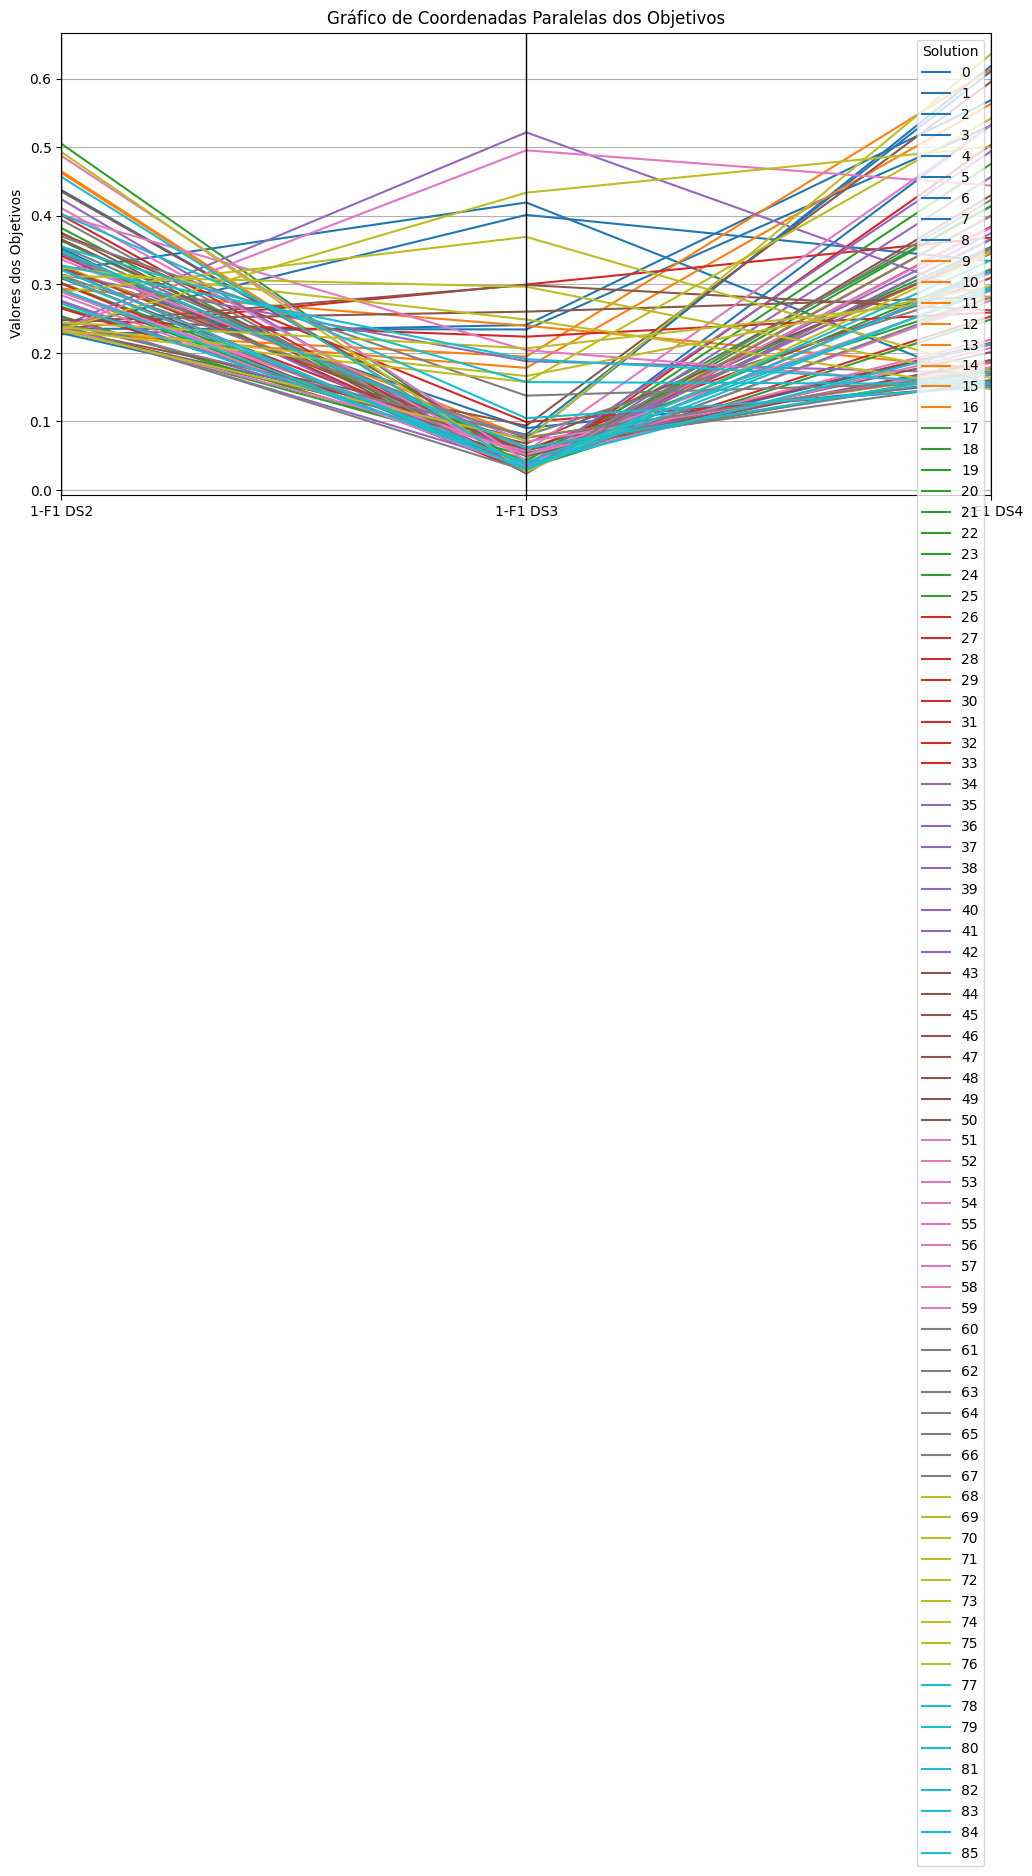

In [92]:
# Extrai os objetivos do resultado carregado
objectives = loaded_res_dt.F

# Converte os objetivos para um DataFrame pandas para facilitar a plotagem
# As colunas devem corresponder aos objetivos na ordem definida:
# [qtd_features, 1-F1 DS1, 1-F1 DS2, 1-F1 DS3, num_neurons]
df_objectives = pd.DataFrame(objectives, columns=['1-F1 DS2', '1-F1 DS3', '1-F1 DS4'])

# Add a column to represent each solution as a class
df_objectives['Solution'] = range(len(df_objectives))

#tenta colocar a quantidade de features e neurônios na mesma ordem de grandeza
#df_objectives['Quantidade de Features'] = df_objectives['Quantidade de Features'] / 10
#df_objectives['Número de Neurônios'] = df_objectives['Número de Neurônios'] / 10

# Cria o gráfico de Coordenadas Paralelas
plt.figure(figsize=(12, 6))
#pd.plotting.parallel_coordinates(df_objectives, 'Quantidade de Features', color=plt.cm.viridis(np.linspace(0, 1, len(df_objectives))))
pd.plotting.parallel_coordinates(df_objectives, class_column='Solution', colormap='tab10')
plt.title('Gráfico de Coordenadas Paralelas dos Objetivos')
plt.ylabel('Valores dos Objetivos')
plt.legend(title='Solution')
plt.grid(True)
plt.show()

In [95]:
import plotly.express as px
import pandas as pd

# Extrai os objetivos do resultado carregado
objectives = loaded_res_dt.F

# Cria um DataFrame pandas para facilitar a integração com o Plotly
df_plot = pd.DataFrame(objectives, columns=['1-F1 DS2', '1-F1 DS3', '1-F1 DS4'])

# Add a column for the solution number
df_plot['Solution'] = range(len(df_plot))

# Plotly Express para criar o scatter plot 3D com pontos esféricos
# 'size' controla o tamanho dos marcadores
# 'color' mapeia a cor dos marcadores para a coluna 'Solution'
# 'hover_data' adiciona informações extras ao passar o mouse sobre os pontos
fig = px.scatter_3d(df_plot,
                    x='1-F1 DS2',
                    y='1-F1 DS3',
                    z='1-F1 DS4',
                    color='Solution', # Color points by solution number
                    color_continuous_scale=px.colors.sequential.Viridis, # Usa o mesmo colormap do Matplotlib
                    opacity=0.7,
                    title='Objectives Scatter Plot 3D',
                    hover_data=['Solution'] # Add solution number to hover data
                    )

# Configura o layout do gráfico
fig.update_layout(
    scene=dict(
        xaxis_title='1-F1 DS2',
        yaxis_title='1-F1 DS3',
        zaxis_title='1-F1 DS4',
        xaxis=dict(
            showgrid=True,
            gridcolor='darkgray', # Add this line to change grid color
            backgroundcolor='GhostWhite', # Add this line to change background color
            nticks=10 # Increase the number of ticks for more gridlines
            #,range=[0.00, 0.001] # Example: Set x-axis range from 0 to 0.1
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor='darkgray', # Add this line to change grid color
            backgroundcolor='GhostWhite', # Add this line to change background color
            nticks=10 # Increase the number of ticks for more gridlines
            #,range=[0.145, 0.17] # Example: Set y-axis range from 0.1 to 0.2
        ),
        zaxis=dict(
            showgrid=True,
            gridcolor='darkgray', # Add this line to change grid color
            backgroundcolor='GhostWhite', # Add this line to change background color
            nticks=10 # Increase the number of ticks for more gridlines
            #,range=[0.04, 0.065] # Example: Set z-axis range from 0 to 0.1
        )
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    coloraxis_showscale=False # Hide the color bar
)

# Mostra o gráfico
fig.show()

### Lista das soluções

In [94]:
# Supondo que 'loaded_res_dt' já foi carregado
# loaded_res_dt.X contém todas as soluções encontradas (cada linha é uma solução)
# A forma de loaded_res_dt.X é (número de soluções, número de variáveis)
# O número de variáveis é o número de features originais + 1 (para o número de neurônios)
n_solutions, n_variables = loaded_res_dt.X.shape
n_features = n_variables - 1 # O número de features é o número total de variáveis menos 1

print(f"Número de soluções encontradas: {n_solutions}")
print(f"Número total de features no problema: {n_features}")

# Obtenha os nomes das colunas do DataFrame original (X)
# Certifique-se de que X está disponível no ambiente
if 'X' in globals() and isinstance(X, pd.DataFrame):
    feature_names = X.columns.tolist()
else:
    print("DataFrame 'X' não encontrado. Não é possível mapear os índices de volta para os nomes das features.")
    feature_names = [f"Feature {i}" for i in range(n_features)] # Crie nomes genéricos se X não estiver disponível

# Obtenha os valores dos objetivos para cada solução
objectives = loaded_res_dt.F

print("\nDetalhes para cada solução encontrada:")
for i in range(n_solutions):
    solution = loaded_res_dt.X[i]
    feature_selection_vector = solution[:-1]  # Exclui a última coluna (número de neurônios)
    num_neurons = int(solution[-1])

    # Encontra os índices onde o valor é 1 (features selecionadas)
    selected_feature_indices = np.where(feature_selection_vector > 0.5)[0] # Use > 0.5 para acomodar floats

    # Mapeia os índices selecionados de volta para os nomes das features
    selected_features = [feature_names[j] for j in selected_feature_indices]

    # Obtém os valores dos objetivos para a solução atual
    current_objectives = objectives[i]

    print(f"Solução {i+1}:")
    print(f"  Número de Neurônios: {num_neurons}")
    print(f"  Quantidade de Features Selecionadas: {len(selected_features)}")
    print(f"  Features Selecionadas: {selected_features}")
    print(f"  Objetivos (1-F1 DS2, 1-F1 DS3, 1-F1 DS4): [{current_objectives[0]:.4f}, {current_objectives[1]:.4f}, {current_objectives[2]:.4f}]")
    print("-" * 20)

Número de soluções encontradas: 86
Número total de features no problema: 40

Detalhes para cada solução encontrada:
Solução 1:
  Número de Neurônios: 8
  Quantidade de Features Selecionadas: 10
  Features Selecionadas: ['OUT_PKTS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'LONGEST_FLOW_PKT', 'MAX_IP_PKT_LEN', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_OUT_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'ICMP_IPV4_TYPE']
  Objetivos (1-F1 DS2, 1-F1 DS3, 1-F1 DS4): [0.2272, 0.2408, 0.5691]
--------------------
Solução 2:
  Número de Neurônios: 3
  Quantidade de Features Selecionadas: 10
  Features Selecionadas: ['PROTOCOL', 'L7_PROTO', 'IN_PKTS', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'SHORTEST_FLOW_PKT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'ICMP_IPV4_TYPE']
  Objetivos (1-F1 DS2, 1-F1 DS3, 1-F1 DS4): [0.3203, 0.4195, 0.1520]
--------------------
Solução 3:
  Número de Neurônios: 8
  Quantidade de Features Selecionadas: 5
  Features S

### Tentativa de melhorar a visualização

#### Coordenadas paralelas

In [97]:
# Extrai os objetivos do resultado carregado
objectives = loaded_res_dt.F

# Converte os objetivos para um DataFrame pandas para facilitar a plotagem
# As colunas devem corresponder aos objetivos na ordem definida:
# [qtd_features, 1-F1 DS1, 1-F1 DS2, 1-F1 DS3, num_neurons]
df_objectives = pd.DataFrame(objectives, columns=['1-F1 DS2', '1-F1 DS3', '1-F1 DS4'])


#aqui vou calcular uma média dos 3 objetivos
#vou pegar a linha com a menor média
#vou pegar 3 linhas com cada um dos menores valores dos objetivos

#aqui vou calcular uma média dos 3 objetivos
df_objectives['Average 1-F1'] = df_objectives[['1-F1 DS2', '1-F1 DS3', '1-F1 DS4']].mean(axis=1)


In [100]:
df_objectives_sorted = df_objectives.sort_values(by='Average 1-F1', ascending=True)
display(df_objectives_sorted.head())

,1-F1 DS2,1-F1 DS3,1-F1 DS4,Average 1-F1
38,0.250697,0.059458,0.187370,0.165841
83,0.310414,0.037503,0.213898,0.187272
56,0.292233,0.051471,0.219642,0.187782
66,0.313057,0.076001,0.175515,0.188191
6,0.323070,0.090289,0.160314,0.191224


In [104]:
# Create a new DataFrame with only the header of df_objectives_sorted
df_best_solutions = df_objectives_sorted.head(1).copy()

In [105]:
df_objectives_sorted = df_objectives.sort_values(by='1-F1 DS2', ascending=True)

In [107]:
df_best_solutions = pd.concat([df_best_solutions, df_objectives_sorted.head(1).copy()], ignore_index=True)

In [109]:
df_objectives_sorted = df_objectives.sort_values(by='1-F1 DS3', ascending=True)

In [110]:
df_best_solutions = pd.concat([df_best_solutions, df_objectives_sorted.head(1).copy()], ignore_index=True)

In [111]:
df_objectives_sorted = df_objectives.sort_values(by='1-F1 DS4', ascending=True)

In [112]:
df_best_solutions = pd.concat([df_best_solutions, df_objectives_sorted.head(1).copy()], ignore_index=True)

In [113]:
display(df_best_solutions)

,1-F1 DS2,1-F1 DS3,1-F1 DS4,Average 1-F1
0,0.250697,0.059458,0.187370,0.165841
1,0.227191,0.240767,0.569067,0.345675
2,0.424343,0.023692,0.457094,0.301709
3,0.324455,0.248742,0.147088,0.240095


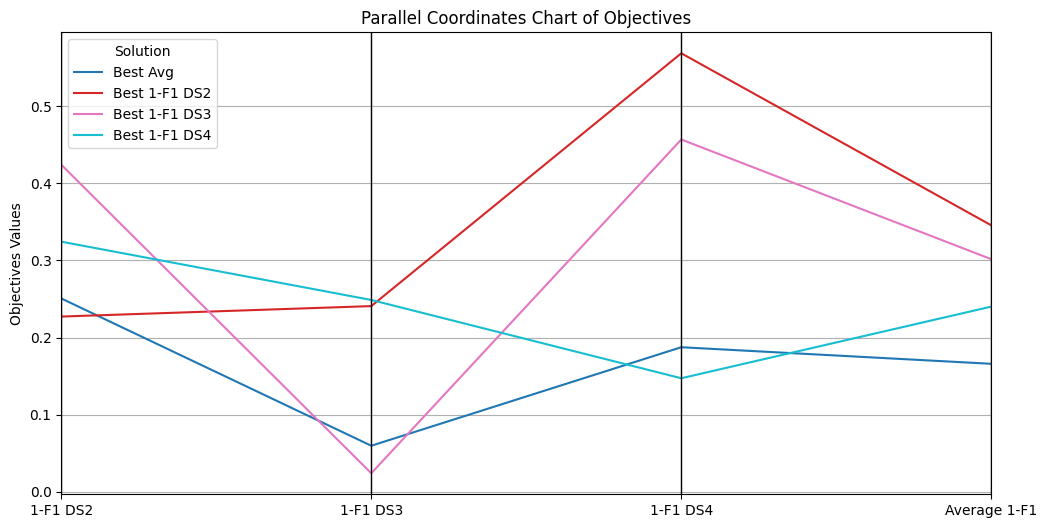

In [115]:
# Add a column to represent each solution as a class
df_best_solutions['Solution'] = ['Best Avg', 'Best 1-F1 DS2', 'Best 1-F1 DS3', 'Best 1-F1 DS4' ]

# Cria o gráfico de Coordenadas Paralelas
plt.figure(figsize=(12, 6))
#pd.plotting.parallel_coordinates(df_objectives, 'Quantidade de Features', color=plt.cm.viridis(np.linspace(0, 1, len(df_objectives))))
pd.plotting.parallel_coordinates(df_best_solutions, class_column='Solution', colormap='tab10')
plt.title('Parallel Coordinates Chart of Objectives')
plt.ylabel('Objectives Values')
plt.legend(title='Solution')
plt.grid(True)
plt.show()

In [116]:
df_objectives_sorted = df_objectives.sort_values(by='1-F1 DS2', ascending=True)
display(df_objectives_sorted.head())

,1-F1 DS2,1-F1 DS3,1-F1 DS4,Average 1-F1
0,0.227191,0.240767,0.569067,0.345675
2,0.228904,0.074476,0.619174,0.307518
13,0.230271,0.194630,0.614330,0.346410
14,0.231505,0.178153,0.563721,0.324460
4,0.232176,0.080741,0.611393,0.308103


In [119]:
# Supondo que 'loaded_res_dt' já foi carregado
# loaded_res_dt.X contém todas as soluções encontradas (cada linha é uma solução)
# A forma de loaded_res_dt.X é (número de soluções, número de variáveis)
# O número de variáveis é o número de features originais + 1 (para o número de neurônios)
n_solutions, n_variables = loaded_res_dt.X.shape
n_features = n_variables - 1 # O número de features é o número total de variáveis menos 1

# Extrai o número de neurônios de cada solução (última coluna de loaded_res_dt.X)
num_neurons = loaded_res_dt.X[:, -1]

# Calcula a mediana do número de neurônios
median_num_neurons = np.median(num_neurons)

# Extrai a parte de seleção de features de cada solução (todas as colunas exceto a última)
feature_selection_vectors = loaded_res_dt.X[:, :-1]

# Calcula a quantidade de features selecionadas para cada solução (contando os valores > 0.5)
selected_features_counts = np.sum(feature_selection_vectors > 0.5, axis=1)

# Calcula a mediana da quantidade de features selecionadas
median_selected_features = np.median(selected_features_counts)

print(f"Mediana do número de neurônios: {median_num_neurons}")
print(f"Mediana da quantidade de features selecionadas: {median_selected_features}")

Mediana do número de neurônios: 3.555528175603561
Mediana da quantidade de features selecionadas: 10.0


Desenho 3D dos melhores objetivos

In [120]:
import plotly.express as px
import pandas as pd

# Extrai os objetivos do resultado carregado
#objectives = loaded_res_dt.F

# Cria um DataFrame pandas para facilitar a integração com o Plotly
df_plot = pd.DataFrame(df_best_solutions, columns=['1-F1 DS2', '1-F1 DS3', '1-F1 DS4'])

# Add a column for the solution name
df_plot['Solution'] = ['Best Avg', 'Best 1-F1 DS2', 'Best 1-F1 DS3', 'Best 1-F1 DS4' ]

# Plotly Express para criar o scatter plot 3D com pontos esféricos
# 'size' controla o tamanho dos marcadores
# 'color' mapeia a cor dos marcadores para a coluna 'Solution'
# 'hover_data' adiciona informações extras ao passar o mouse sobre os pontos
fig = px.scatter_3d(df_plot,
                    x='1-F1 DS2',
                    y='1-F1 DS3',
                    z='1-F1 DS4',
                    color_continuous_scale=px.colors.sequential.Viridis, # Usa o mesmo colormap do Matplotlib
                    opacity=0.7,
                    title='Objectives Scatter Plot 3D',
                    hover_data=['Solution'] # Add solution number to hover data
                    )

# Configura o layout do gráfico
fig.update_layout(
    scene=dict(
        xaxis_title='1-F1 DS2',
        yaxis_title='1-F1 DS3',
        zaxis_title='1-F1 DS4',
        xaxis=dict(
            showgrid=True,
            gridcolor='darkgray', # Add this line to change grid color
            backgroundcolor='GhostWhite', # Add this line to change background color
            nticks=10 # Increase the number of ticks for more gridlines
            #,range=[0.00, 0.001] # Example: Set x-axis range from 0 to 0.1
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor='darkgray', # Add this line to change grid color
            backgroundcolor='GhostWhite', # Add this line to change background color
            nticks=10 # Increase the number of ticks for more gridlines
            #,range=[0.145, 0.17] # Example: Set y-axis range from 0.1 to 0.2
        ),
        zaxis=dict(
            showgrid=True,
            gridcolor='darkgray', # Add this line to change grid color
            backgroundcolor='GhostWhite', # Add this line to change background color
            nticks=10 # Increase the number of ticks for more gridlines
            #,range=[0.04, 0.065] # Example: Set z-axis range from 0 to 0.1
        )
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    coloraxis_showscale=False # Hide the color bar
)

# Mostra o gráfico
fig.show()

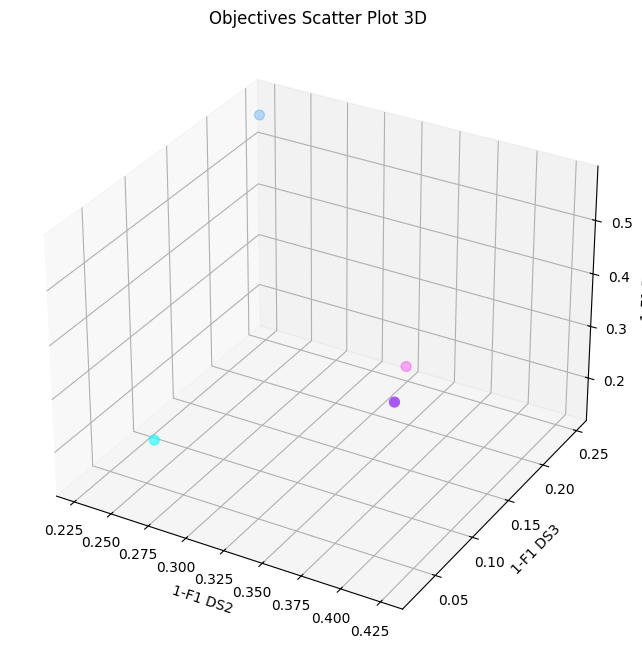

In [139]:
# Assuming df_plot is already created and contains the objective columns and 'Solution'

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(df_plot['1-F1 DS2'], df_plot['1-F1 DS3'], df_plot['1-F1 DS4'],
                     c=df_plot.index, cmap='cool', s=50) # Using index for color and 'viridis' colormap

# Labels and Title
ax.set_xlabel('1-F1 DS2')
ax.set_ylabel('1-F1 DS3')
ax.set_zlabel('1-F1 DS4')
ax.set_title('Objectives Scatter Plot 3D')

# Add a color bar
# cbar = fig.colorbar(scatter, pad=0.1)
# cbar.set_label('Solution Index')

plt.show()